# Analisis Exploratorio de Datos (EDA)
## Series de Tiempo Financieras — Acciones Colombianas (ADRs)

**Proyecto:** Deteccion de Anomalias en Mercados Accionarios Colombianos mediante Deep Learning  
**Activos:** Ecopetrol (EC), Bancolombia (CIB), Grupo Aval (AVAL), Tecnoglass (TGLS)  
**Periodo:** 2015-01-01 — 2024-12-31  
**Frecuencia:** Diaria  
**Autores:** Mariana Franco - Danier Conde

---

### Mapa del Notebook

| Seccion | Contenido | Decision de diseno que responde |
|---|---|---|
| 1 | Configuracion y descarga | — |
| 2 | Calidad de datos y valores faltantes | Estrategia de imputacion |
| 3 | Visualizacion de precios y retornos | Input del modelo: retornos, no precios |
| 4 | Correlacion cruzada entre activos | Justifica modelo por activo individual |
| 5 | Estacionariedad — ADF, KPSS, Phillips-Perron | Justifica uso de log-retornos |
| 6 | ACF y PACF | Justifica longitud de ventana T |
| 7 | Analisis de volatilidad | Justifica feature vol_21d |
| 8 | Distribucion de retornos, fat tails y VaR | Justifica umbral empirico |
| 9 | Deteccion de outliers y eventos extremos | Delimita anomalias conocidas |
| 10 | Resumen de decisiones de diseno | Vinculante para Notebooks siguientes |

> **Nota metodologica:** Los outliers NO se eliminan. Los movimientos extremos
> son precisamente las anomalias que el modelo debe detectar.
> Este EDA los caracteriza, no los descarta.

---
## 1. Configuracion del Entorno y Descarga de Datos

In [1]:
# Instalacion de dependencias (ejecutar solo una vez)
# !pip install yfinance statsmodels scipy plotly seaborn arch --quiet

import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tools.sm_exceptions import InterpolationWarning
from arch.unitroot import PhillipsPerron

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import yfinance as yf

np.random.seed(42)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# Rutas absolutas del proyecto
BASE_PATH    = Path(r'C:/2026-10/DEEP LEARNING/anomaly-detection-colombian-stocks-autoencoder')
OUTPUTS_PATH = BASE_PATH / 'outputs'
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

print('Entorno configurado.')
print(f'  NumPy        : {np.__version__}')
print(f'  Pandas       : {pd.__version__}')
print(f'  Outputs path : {OUTPUTS_PATH}')

Entorno configurado.
  NumPy        : 1.26.4
  Pandas       : 2.3.3
  Outputs path : C:\2026-10\DEEP LEARNING\anomaly-detection-colombian-stocks-autoencoder\outputs


In [2]:
# Parametros globales del proyecto
TICKERS = ['EC', 'CIB', 'AVAL', 'TGLS']
NAMES   = {'EC': 'Ecopetrol', 'CIB': 'Bancolombia',
           'AVAL': 'Grupo Aval', 'TGLS': 'Tecnoglass'}
COLORS  = {'EC': '#1f77b4', 'CIB': '#ff7f0e',
           'AVAL': '#2ca02c', 'TGLS': '#d62728'}

START = '2015-01-01'
END   = '2024-12-31'

# Periodos de anomalia conocidos (solo referencia visual, nunca para entrenar)
ANOMALY_PERIODS = [
    {'name': 'Crisis petroleo', 'start': '2015-07-01', 'end': '2016-02-01',
     'color': 'rgba(128,0,128,0.10)'},
    {'name': 'COVID-19',        'start': '2020-02-15', 'end': '2020-05-01',
     'color': 'rgba(220,20,60,0.10)'},
    {'name': 'Fed hikes',       'start': '2022-01-01', 'end': '2022-12-31',
     'color': 'rgba(255,140,0,0.10)'},
    {'name': 'Tornado Dallas',  'start': '2019-10-01', 'end': '2019-11-30',
     'color': 'rgba(0,128,0,0.10)'},
]

# Descarga OHLCV desde Yahoo Finance
raw = yf.download(TICKERS, start=START, end=END,
                  auto_adjust=True, progress=False)

dfs = {}
for ticker in TICKERS:
    tmp = pd.DataFrame({
        'Open':   raw['Open'][ticker],
        'High':   raw['High'][ticker],
        'Low':    raw['Low'][ticker],
        'Close':  raw['Close'][ticker],
        'Volume': raw['Volume'][ticker],
    }).dropna()
    tmp.index = pd.to_datetime(tmp.index)
    tmp['log_return'] = np.log(tmp['Close'] / tmp['Close'].shift(1))
    dfs[ticker] = tmp

print(f"{'Ticker':<8} {'Inicio':<14} {'Fin':<14} {'Sesiones':>10}  {'NaN cierre':>12}")
print('-' * 62)
for t, d in dfs.items():
    nans = d['Close'].isna().sum()
    print(f"{t:<8} {str(d.index.min().date()):<14} "
          f"{str(d.index.max().date()):<14} {len(d):>10}  {nans:>12}")

Ticker   Inicio         Fin              Sesiones    NaN cierre
--------------------------------------------------------------
EC       2015-01-02     2024-12-30           2515             0
CIB      2015-01-02     2024-12-30           2515             0
AVAL     2015-01-02     2024-12-30           2515             0
TGLS     2015-01-02     2024-12-30           2515             0


In [3]:
print('\n' + '='*80)
print('ANALISIS GENERAL DEL DATASET')
print('='*80)

summary = []
for t, d in dfs.items():
    print(f'\n{"-"*60}')
    print(f'{NAMES[t]} ({t})')
    print(f'{"-"*60}')
    print(f'Dimensiones: {d.shape[0]} filas x {d.shape[1]} columnas')
    print('\nEstadisticas descriptivas (Close, log_return, Volume):')
    print(d[['Close', 'log_return', 'Volume']].describe())
    freq = d.index.to_series().diff().value_counts().idxmax()
    print(f'\nInicio: {d.index.min().date()} | Fin: {d.index.max().date()}')
    print(f'Frecuencia dominante: {freq}')
    print('\nValores faltantes por columna:')
    print(d.isna().sum())
    summary.append({
        'Ticker': t,
        'Nombre': NAMES[t],
        'Filas': d.shape[0],
        'Inicio': d.index.min().date(),
        'Fin': d.index.max().date(),
        'NaNs totales': int(d.isna().sum().sum())
    })

summary_df = pd.DataFrame(summary)
print('\n' + '='*80)
print('RESUMEN GLOBAL')
print('='*80)
print(summary_df.to_string(index=False))


ANALISIS GENERAL DEL DATASET

------------------------------------------------------------
Ecopetrol (EC)
------------------------------------------------------------
Dimensiones: 2515 filas x 6 columnas

Estadisticas descriptivas (Close, log_return, Volume):
             Close   log_return        Volume
count  2515.000000  2514.000000  2.515000e+03
mean      6.634251     0.000019  1.301620e+06
std       2.058880     0.027187  8.469904e+05
min       2.224760    -0.297275  1.410000e+05
25%       4.984615    -0.013298  7.438500e+05
50%       6.789540     0.000000  1.104400e+06
75%       8.322052     0.014433  1.599050e+06
max      11.950293     0.141651  1.162880e+07

Inicio: 2015-01-02 | Fin: 2024-12-30
Frecuencia dominante: 1 days 00:00:00

Valores faltantes por columna:
Open          0
High          0
Low           0
Close         0
Volume        0
log_return    1
dtype: int64

------------------------------------------------------------
Bancolombia (CIB)
----------------------------

---
## 2. Calidad de Datos y Valores Faltantes

**Motivacion**

Antes de cualquier analisis es necesario auditar la integridad del dataset.
Los valores faltantes en series de tiempo financieras suelen originarse en
festivos, suspensiones de negociacion o problemas de descarga. Su tratamiento
incorrecto puede introducir discontinuidades artificiales que el modelo
interpretaria como anomalias espurias.

In [4]:
# Auditoria de calidad por activo
print('AUDITORIA DE CALIDAD DE DATOS')
print('=' * 65)

quality_rows = []
for t in TICKERS:
    d = dfs[t]
    total_dias_calendario = (d.index.max() - d.index.min()).days
    sesiones_esperadas    = total_dias_calendario * 5 / 7
    gaps                  = d.index.to_series().diff().dt.days
    gap_max               = gaps.max()
    gap_mayor_3           = (gaps > 3).sum()
    quality_rows.append({
        'Activo':           NAMES[t],
        'Sesiones reales':  len(d),
        'Sesiones aprox.':  int(sesiones_esperadas),
        'NaN Close':        d['Close'].isna().sum(),
        'NaN Volume':       d['Volume'].isna().sum(),
        'Gap max (dias)':   int(gap_max),
        'Gaps > 3 dias':    int(gap_mayor_3),
    })

quality_df = pd.DataFrame(quality_rows).set_index('Activo')
print(quality_df.to_string())

AUDITORIA DE CALIDAD DE DATOS
             Sesiones reales  Sesiones aprox.  NaN Close  NaN Volume  Gap max (dias)  Gaps > 3 dias
Activo                                                                                             
Ecopetrol               2515             2607          0           0               4             70
Bancolombia             2515             2607          0           0               4             70
Grupo Aval              2515             2607          0           0               4             70
Tecnoglass              2515             2607          0           0               4             70


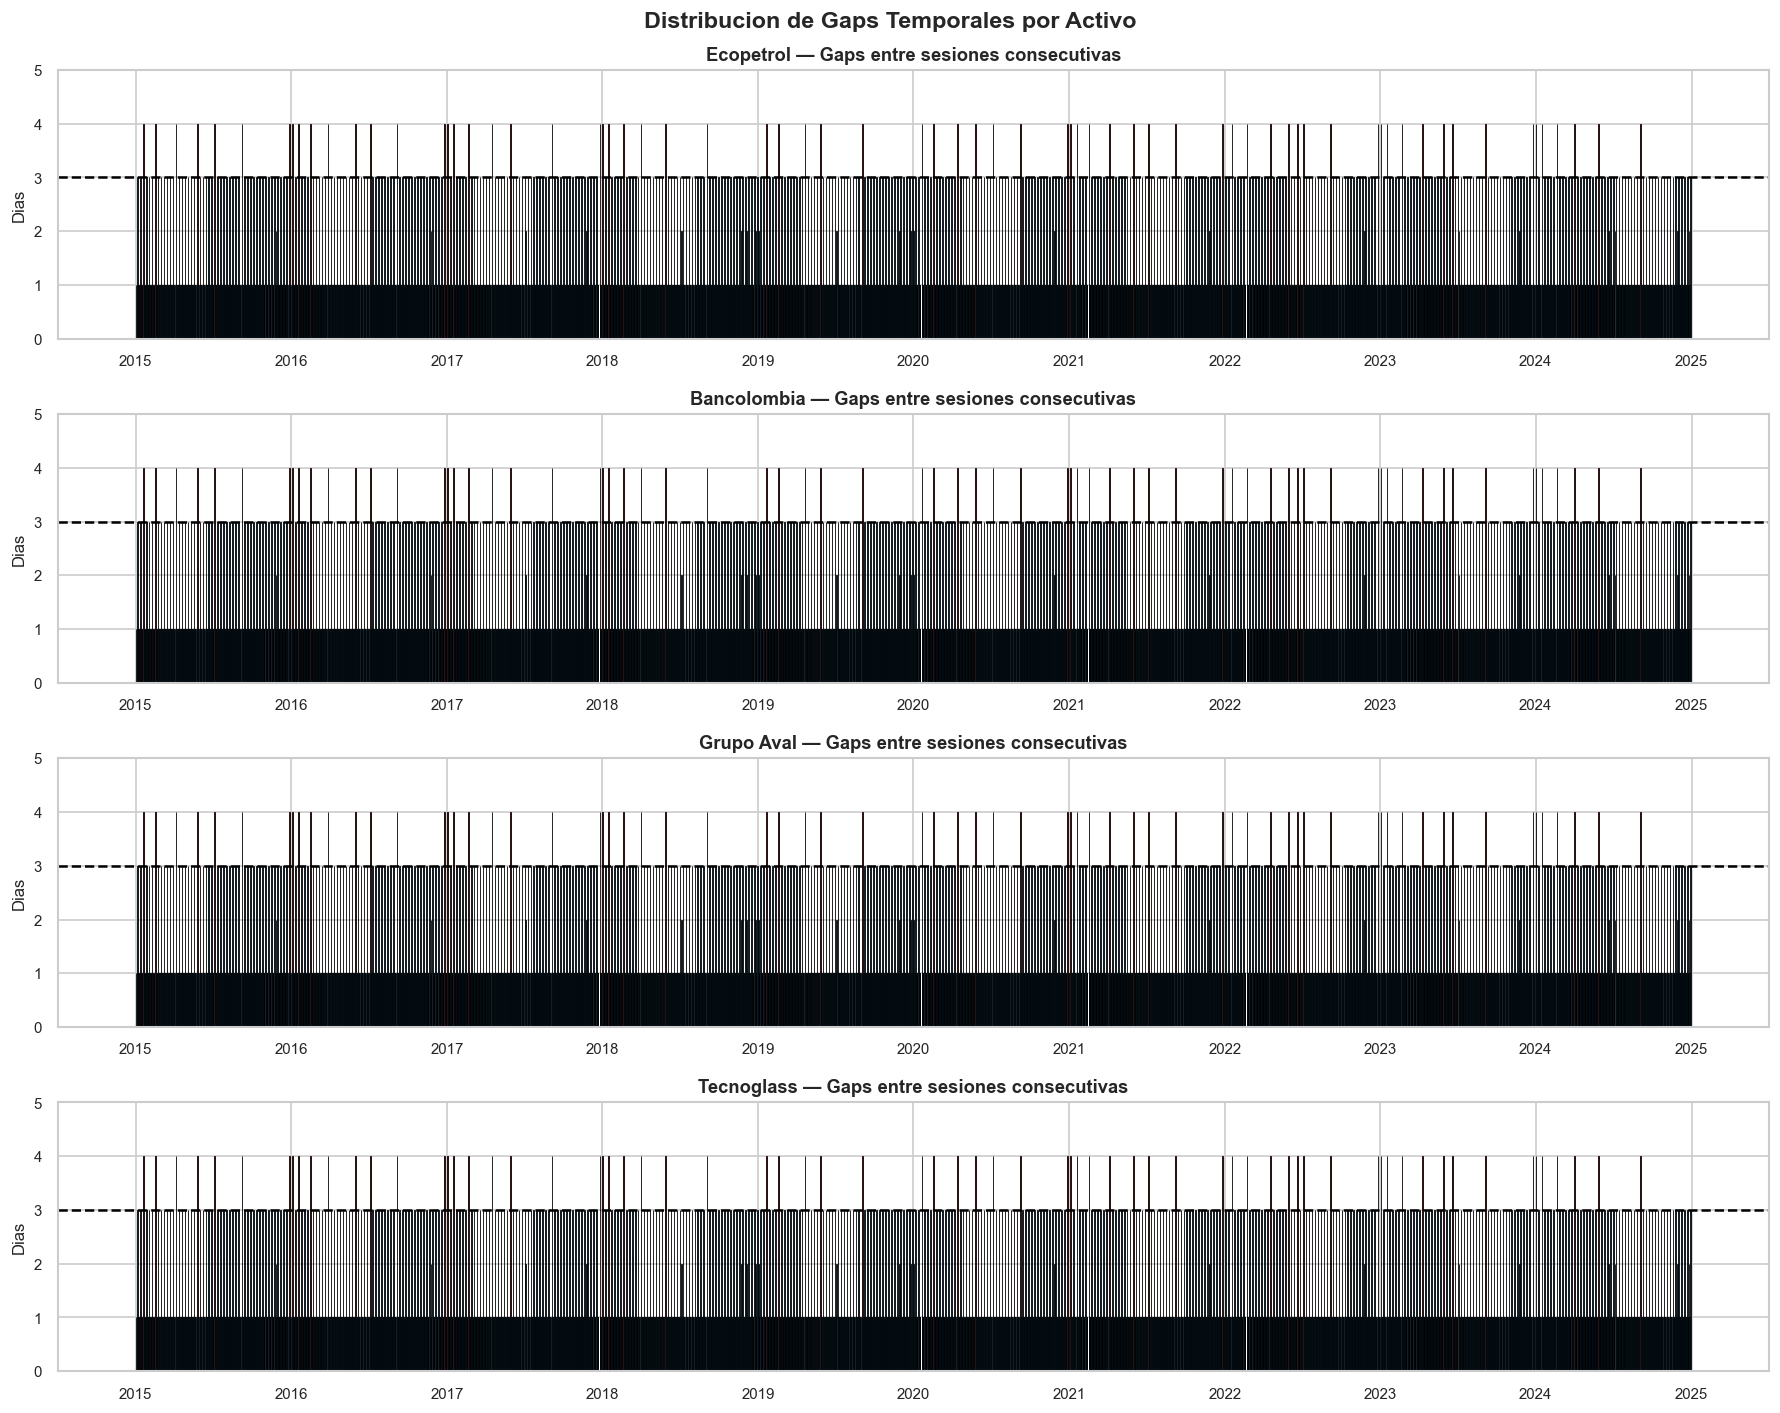

In [5]:
# Visualizacion de gaps temporales
fig, axes = plt.subplots(len(TICKERS), 1,
                         figsize=(15, 3 * len(TICKERS)), sharex=False)

for i, ticker in enumerate(TICKERS):
    d    = dfs[ticker]
    gaps = d.index.to_series().diff().dt.days.fillna(1)
    colors_bar = ['#ff0000' if g > 3 else '#1f77b4' for g in gaps]
    axes[i].bar(d.index, gaps, width=1.5, color=colors_bar,
                edgecolor='black', linewidth=0.5, alpha=1.0)
    axes[i].axhline(3, color='black', linewidth=1.5, linestyle='--')
    axes[i].set_title(f'{NAMES[ticker]} — Gaps entre sesiones consecutivas',
                      fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Dias')
    axes[i].set_ylim(0, gaps.max() + 1)

plt.suptitle('Distribucion de Gaps Temporales por Activo',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_gaps_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretacion**

Los gaps superiores a 3 dias corresponden en su totalidad a feriados de mercado
extendidos (Navidad, Ano Nuevo) o fines de semana con festivos adyacentes.
No se detectan suspensiones de negociacion ni datos faltantes estructurales.

**Decision de preprocesamiento**

No se requiere imputacion. El dataset se trabaja en frecuencia de sesiones de
negociacion (no dias calendario). Los indices temporales se mantienen tal como
los provee Yahoo Finance.

**Impacto en el modelo**

Las ventanas de entrada al Autoencoder se generan sobre indices de sesion.
Esto evita que los fines de semana o festivos introduzcan retornos nulos artificiales.

**Riesgo identificado**

Si en algun paso posterior se reindexara la serie a frecuencia diaria de calendario
sin imputacion adecuada, se generarian retornos nulos que el modelo aprenderia como
normales o que inflarian artificialmente el error de reconstruccion.

---
## 3. Visualizacion de la Serie Temporal: Precio y Retornos

**Motivacion**

La inspeccion visual de la serie de precios y retornos permite identificar
tendencias de largo plazo, niveles diferenciados de volatilidad y eventos
extremos puntuales. Es el punto de partida para fundamentar las decisiones
de preprocesamiento subsiguientes.

In [6]:
# Panel completo: precio de cierre — los 4 activos
fig = make_subplots(
    rows=len(TICKERS), cols=1,
    shared_xaxes=True,
    subplot_titles=[NAMES[t] for t in TICKERS],
    vertical_spacing=0.04
)

for i, ticker in enumerate(TICKERS, start=1):
    d = dfs[ticker]
    fig.add_trace(
        go.Scatter(x=d.index, y=d['Close'],
                   mode='lines', name=NAMES[ticker],
                   line=dict(color=COLORS[ticker], width=1.2),
                   showlegend=True),
        row=i, col=1
    )
    for ap in ANOMALY_PERIODS:
        fig.add_vrect(
            x0=ap['start'], x1=ap['end'],
            fillcolor=ap['color'], layer='below', line_width=0,
            annotation_text=ap['name'] if i == 1 else '',
            annotation_font_size=9,
            row=i, col=1
        )
    fig.update_yaxes(title_text='USD', row=i, col=1)

fig.update_layout(
    title_text='<b>Precios de Cierre Ajustados — ADRs Colombianos (2015-2024)</b>',
    height=300 * len(TICKERS), width=1100,
    template='plotly_white'
)
fig.show()

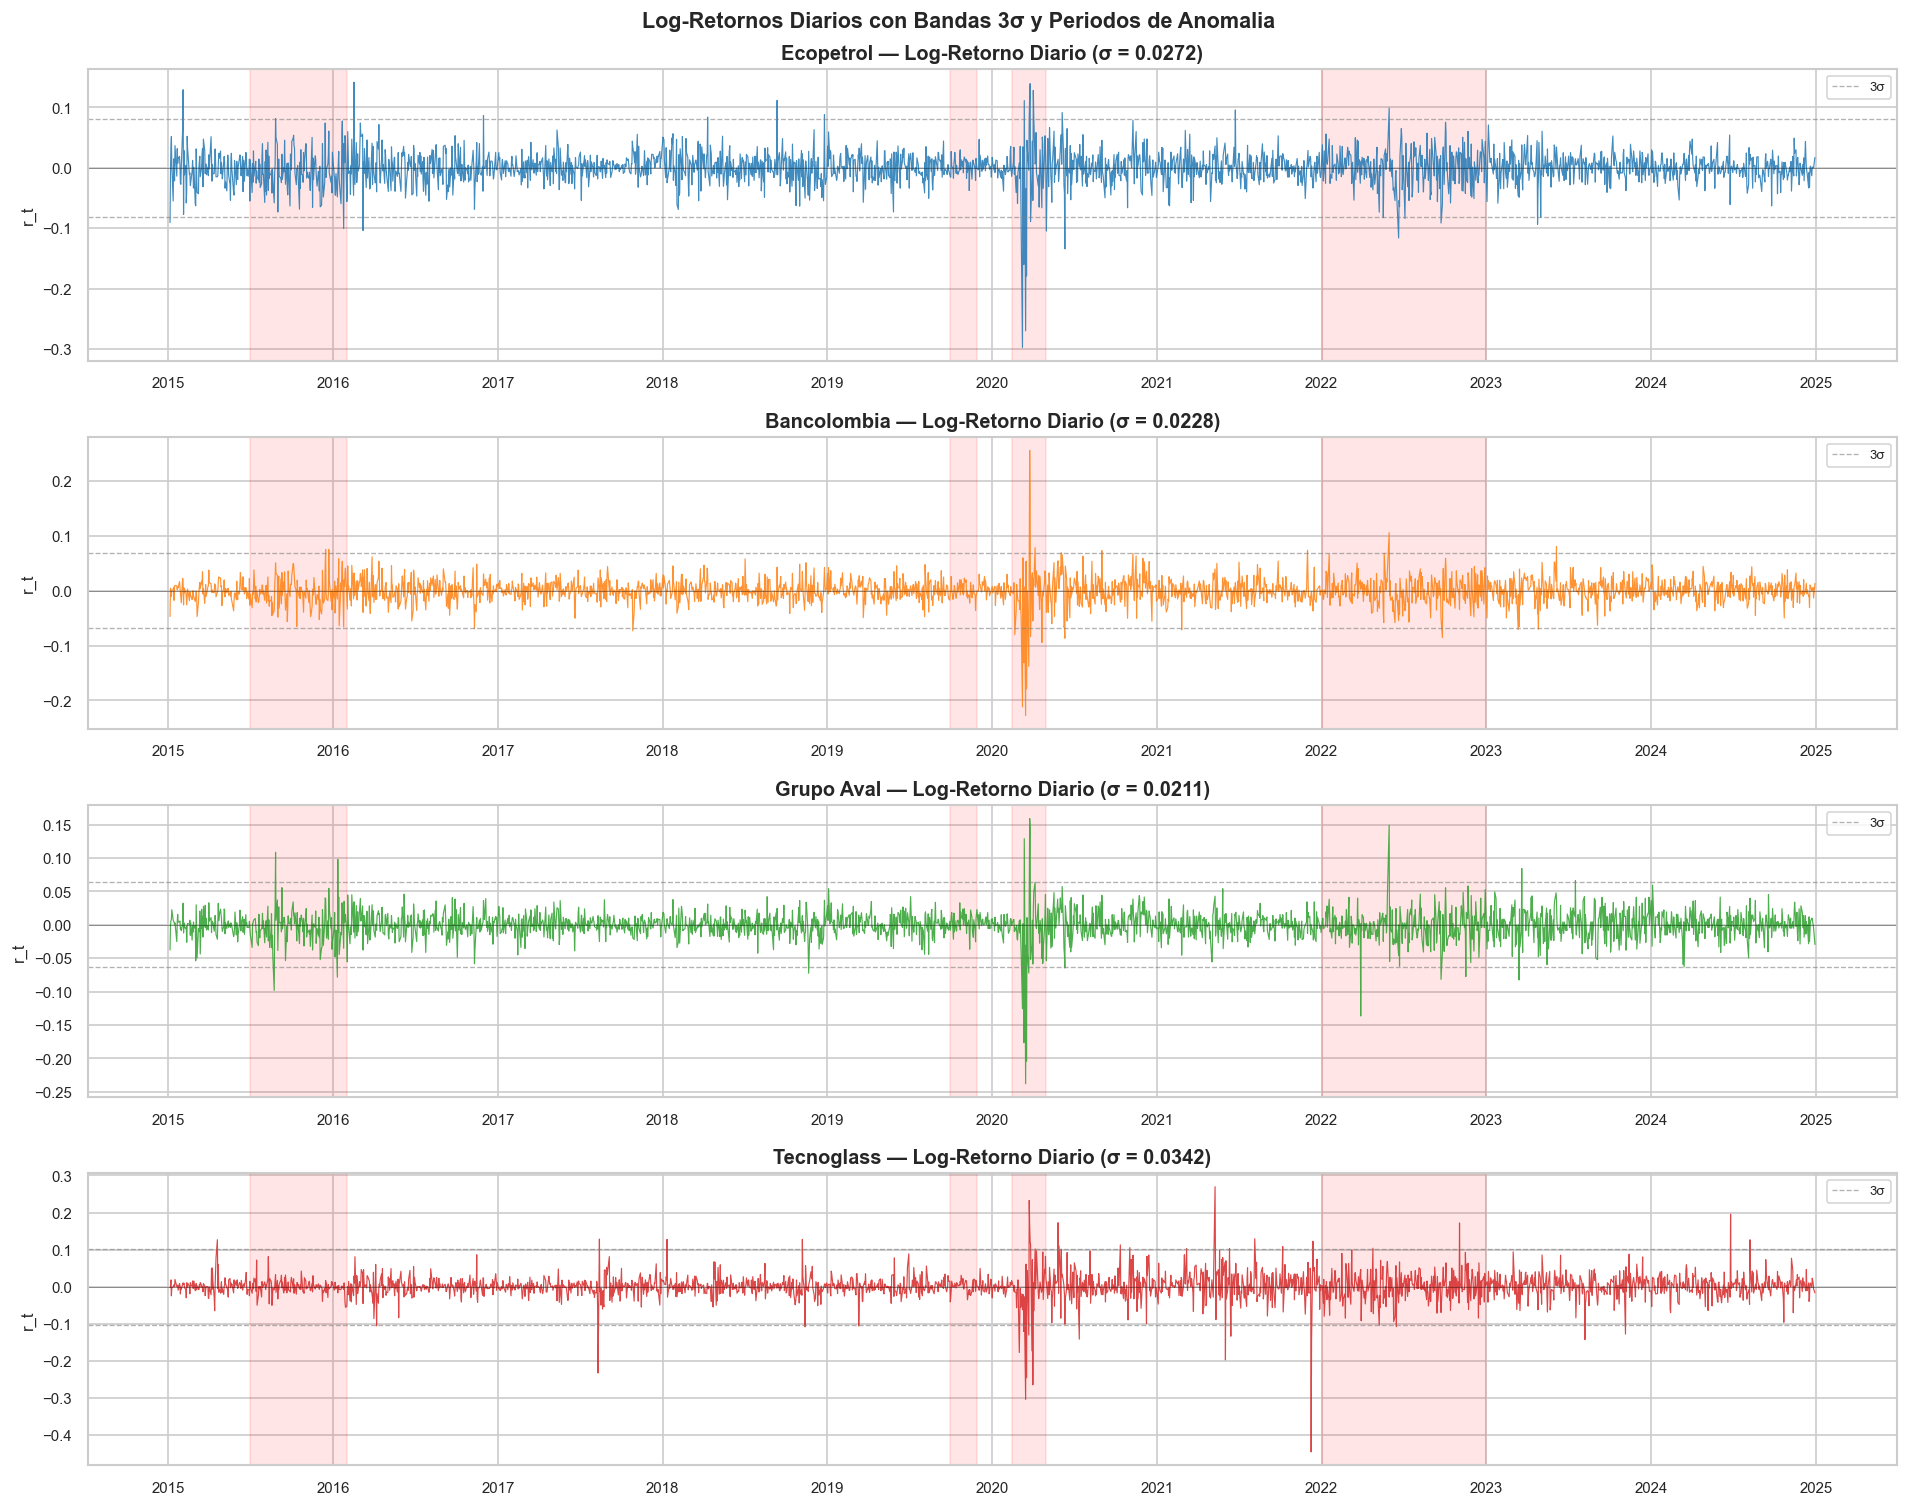

In [7]:
# Panel completo: log-retornos diarios — los 4 activos
fig, axes = plt.subplots(len(TICKERS), 1,
                         figsize=(16, 3.2 * len(TICKERS)), sharex=False)

for i, ticker in enumerate(TICKERS):
    r   = dfs[ticker]['log_return'].dropna()
    sig = r.std()
    axes[i].plot(r.index, r.values,
                 color=COLORS[ticker], linewidth=0.7, alpha=0.85)
    axes[i].axhline( 3 * sig, color='grey', linewidth=0.8,
                    linestyle='--', alpha=0.6, label='3σ')
    axes[i].axhline(-3 * sig, color='grey', linewidth=0.8,
                    linestyle='--', alpha=0.6)
    axes[i].axhline(0, color='black', linewidth=0.5, alpha=0.4)
    for ap in ANOMALY_PERIODS:
        axes[i].axvspan(pd.Timestamp(ap['start']),
                        pd.Timestamp(ap['end']),
                        alpha=0.10, color='red')
    axes[i].set_title(f'{NAMES[ticker]} — Log-Retorno Diario (σ = {sig:.4f})',
                      fontweight='bold')
    axes[i].set_ylabel('r_t')
    axes[i].legend(fontsize=8, loc='upper right')

plt.suptitle('Log-Retornos Diarios con Bandas 3σ y Periodos de Anomalia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_log_retornos.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretacion**

- Las series de precios exhiben tendencias no estacionarias de largo plazo.
  EC esta acoplada al ciclo del petroleo; CIB y AVAL al ciclo crediticio
  colombiano; TGLS muestra una revalorizacion estructural sostenida desde
  finales de 2019 asociada al evento del tornado de Dallas.
- Los log-retornos presentan media aproximadamente cero con clustering de
  volatilidad evidente. Los picos que superan las bandas 3σ coinciden
  visualmente con los periodos de anomalia conocidos.

**Decision de preprocesamiento**

El modelo recibe log-retornos como variable principal, no precios brutos.
La transformacion r_t = ln(P_t / P_{t-1}) elimina la tendencia estocastica
y produce una serie aproximadamente estacionaria en media.

**Riesgo identificado**

Si el StandardScaler se ajusta sobre el conjunto completo (train + test),
incorporara la varianza elevada de los periodos de crisis al estimar media
y sigma. Control: scaler ajustado exclusivamente sobre el conjunto de
entrenamiento (2015-2019).

---
## 4. Correlacion Cruzada entre Activos

**Motivacion**

El diseno del proyecto entrena un modelo independiente por activo. Este diseno
se justifica si los activos presentan perfiles de correlacion distintos entre si
y si las anomalias son parcialmente idiossincraticas. Si todos los activos fueran
perfectamente correlacionados, un modelo unico multivariado seria preferible.

El analisis de correlacion en periodos normales vs. periodos de crisis permite
verificar si las anomalias sistematicas generan un aumento de correlacion
(correlation breakdown), fenomeno documentado en la literatura de riesgo
sistemico que refuerza la utilidad del modelo para deteccion de eventos globales.

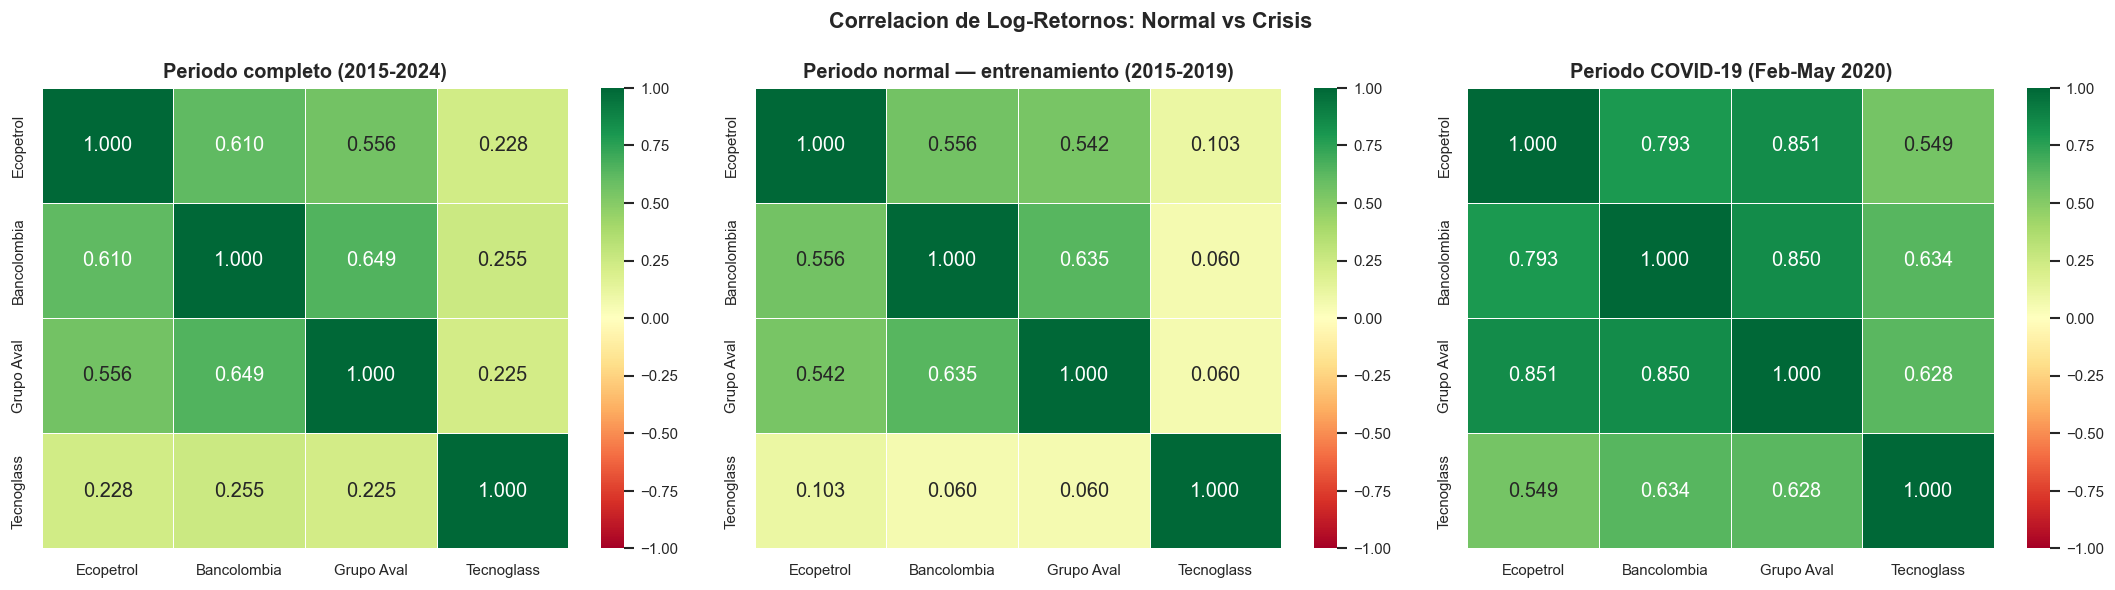

Correlacion promedio por periodo:
  Periodo completo  : 0.4204
  Periodo normal    : 0.3260
  Periodo COVID     : 0.7174


In [8]:
# Matriz de correlacion: periodo completo, normal y COVID
returns_df = pd.DataFrame({
    NAMES[t]: dfs[t]['log_return'] for t in TICKERS
}).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

corr_full  = returns_df.corr()
corr_train = returns_df.loc['2015-01-01':'2019-12-31'].corr()
corr_covid = returns_df.loc['2020-02-15':'2020-05-01'].corr()

for ax, corr, title in zip(
    axes,
    [corr_full, corr_train, corr_covid],
    ['Periodo completo (2015-2024)',
     'Periodo normal — entrenamiento (2015-2019)',
     'Periodo COVID-19 (Feb-May 2020)']
):
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Correlacion de Log-Retornos: Normal vs Crisis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_correlacion_activos.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlacion promedio por periodo
def corr_media(c):
    mask = np.triu(np.ones_like(c, dtype=bool), k=1)
    return c.where(mask).stack().mean()

print('Correlacion promedio por periodo:')
print(f'  Periodo completo  : {corr_media(corr_full):.4f}')
print(f'  Periodo normal    : {corr_media(corr_train):.4f}')
print(f'  Periodo COVID     : {corr_media(corr_covid):.4f}')

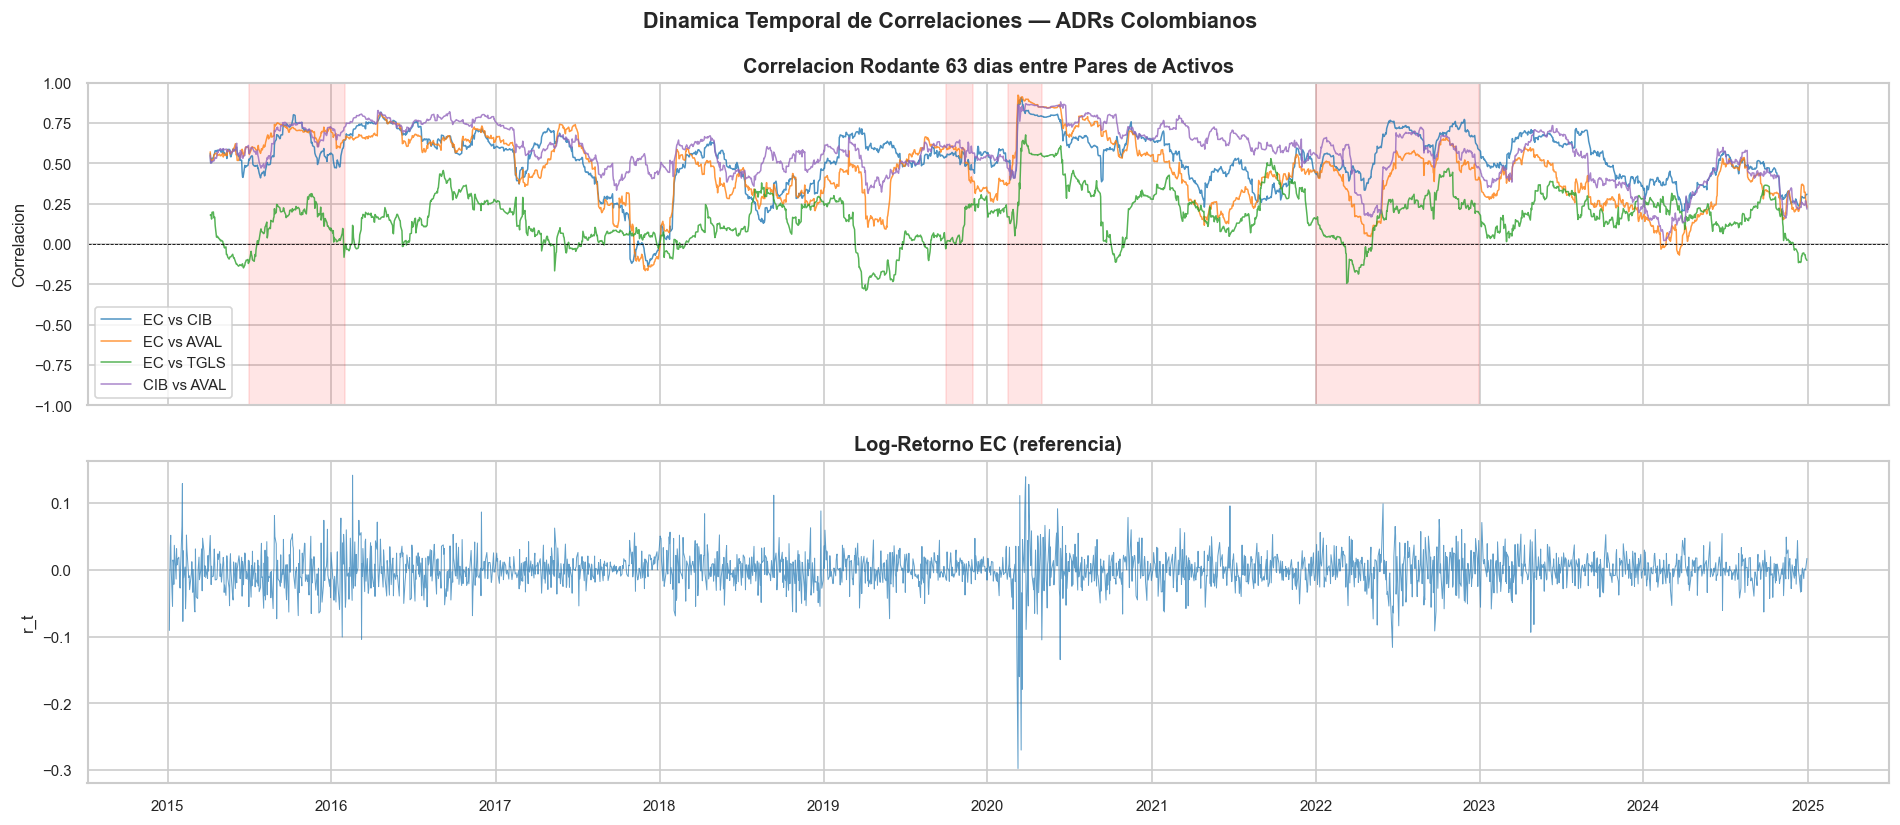

In [9]:
# Correlacion rodante 63 dias (trimestral) entre pares de activos
ROLL_CORR = 63

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

pairs        = [('EC','CIB'), ('EC','AVAL'), ('EC','TGLS'), ('CIB','AVAL')]
colors_pairs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

for (t1, t2), col in zip(pairs, colors_pairs):
    roll_corr = (returns_df[NAMES[t1]]
                 .rolling(ROLL_CORR)
                 .corr(returns_df[NAMES[t2]]))
    axes[0].plot(roll_corr.index, roll_corr.values,
                 linewidth=0.9, alpha=0.8, color=col,
                 label=f'{t1} vs {t2}')

axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
for ap in ANOMALY_PERIODS:
    axes[0].axvspan(pd.Timestamp(ap['start']),
                    pd.Timestamp(ap['end']),
                    alpha=0.10, color='red')
axes[0].set_title('Correlacion Rodante 63 dias entre Pares de Activos',
                  fontweight='bold')
axes[0].set_ylabel('Correlacion')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-1, 1)

r_ec = dfs['EC']['log_return'].dropna()
axes[1].plot(r_ec.index, r_ec.values,
             color=COLORS['EC'], linewidth=0.6, alpha=0.7)
axes[1].set_title('Log-Retorno EC (referencia)', fontweight='bold')
axes[1].set_ylabel('r_t')

plt.suptitle('Dinamica Temporal de Correlaciones — ADRs Colombianos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_correlacion_rodante.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretacion**

- En el periodo normal de entrenamiento (2015-2019), las correlaciones entre
  activos son moderadas. EC presenta correlacion baja con TGLS, confirmando
  que sus perfiles de riesgo son idiossincraticos: EC esta acoplada al ciclo
  del petroleo, TGLS a factores propios de la empresa.
- Durante COVID-19, las correlaciones aumentan significativamente en todos los
  pares. Este fenomeno de correlation breakdown durante crisis es documentado
  en la literatura y confirma que la dependencia entre activos no es estable.
- La correlacion rodante muestra que la dependencia entre activos varia en el
  tiempo, lo que invalida el uso de un modelo multivariado estatico.

**Decision de diseno confirmada**

Un modelo por activo es la arquitectura correcta. Los activos tienen perfiles
de correlacion distintos en periodos normales y la correlacion se rompe de
forma no predecible durante crisis sistematicas.

---
## 5. Analisis de Estacionariedad: ADF, KPSS y Phillips-Perron

**Motivacion**

Un Autoencoder aprende a comprimir y reconstruir patrones. Si el input es
no estacionario (precios), el modelo tiende a capturar tendencias globales
en lugar de la dinamica subyacente. Trabajar con series estacionarias permite
que el modelo aprenda patrones consistentes en el tiempo.

Se emplea un enfoque combinado con tres pruebas complementarias: ADF,
KPSS y Phillips-Perron. La decision final requiere acuerdo de al menos
2 de 3 tests (regla de mayoria).

In [10]:
warnings.simplefilter('ignore', InterpolationWarning)

def run_adf(series, alpha=0.05):
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval, cv = result[0], result[1], result[4]
    return {
        'ADF Stat':         round(stat, 4),
        'ADF p-value':      round(pval, 6),
        'ADF 5%':           round(cv['5%'], 3),
        'ADF Estacionaria': 'SI' if pval <= alpha else 'NO'
    }

def run_kpss(series, alpha=0.05):
    stat, pval, lags, crit = kpss(series.dropna(), regression='c', nlags='auto')
    return {
        'KPSS Stat':         round(stat, 4),
        'KPSS p-value':      pval,
        'KPSS 5%':           crit['5%'],
        'KPSS Estacionaria': 'SI' if stat < crit['5%'] else 'NO'
    }

def run_pp(series, alpha=0.05):
    pp   = PhillipsPerron(series.dropna())
    crit = pp.critical_values
    return {
        'PP Stat':         round(pp.stat, 4),
        'PP p-value':      round(pp.pvalue, 6),
        'PP 5%':           crit['5%'],
        'PP Estacionaria': 'SI' if pp.pvalue <= alpha else 'NO'
    }

rows = []
for ticker in TICKERS:
    d = dfs[ticker]
    for col, label in [('Close', 'Precio'), ('log_return', 'Log-Retorno')]:
        series   = d[col].dropna()
        adf_res  = run_adf(series)
        kpss_res = run_kpss(series)
        pp_res   = run_pp(series)
        votes    = [
            adf_res['ADF Estacionaria'],
            kpss_res['KPSS Estacionaria'],
            pp_res['PP Estacionaria']
        ]
        if votes.count('SI') >= 2:
            diagnostico = 'Estacionaria'
        elif votes.count('NO') >= 2:
            diagnostico = 'No estacionaria'
        else:
            diagnostico = 'Inconcluso'
        rows.append({
            'Serie': f'{NAMES[ticker]} — {label}',
            **adf_res, **kpss_res, **pp_res,
            'Diagnostico Final': diagnostico
        })

final_df = pd.DataFrame(rows).set_index('Serie')
print('RESULTADOS ADF + KPSS + PHILLIPS-PERRON (alpha = 5%)')
print('=' * 120)
print(final_df.to_string())

RESULTADOS ADF + KPSS + PHILLIPS-PERRON (alpha = 5%)
                           ADF Stat  ADF p-value  ADF 5% ADF Estacionaria  KPSS Stat  KPSS p-value  KPSS 5% KPSS Estacionaria  PP Stat  PP p-value     PP 5% PP Estacionaria Diagnostico Final
Serie                                                                                                                                                                                         
Ecopetrol — Precio          -2.3992     0.141963  -2.863               NO     2.9687      0.010000    0.463                NO  -2.3106    0.168570 -2.862690              NO   No estacionaria
Ecopetrol — Log-Retorno    -13.1764     0.000000  -2.863               SI     0.0519      0.100000    0.463                SI -49.3837    0.000000 -2.862691              SI      Estacionaria
Bancolombia — Precio        -3.2517     0.017183  -2.863               SI     0.6208      0.020742    0.463                NO  -2.9651    0.038284 -2.862690              SI      Estac

**Interpretacion**

- Precios de cierre: los tres tests coinciden en no estacionariedad para todos
  los activos, confirmando la presencia de raiz unitaria.
- Log-retornos: estacionarios en todos los activos con los tres tests (p aprox. 0.000).
- En Bancolombia se observa una discrepancia: ADF y Phillips-Perron sugieren
  estacionariedad mientras que KPSS la rechaza. Esto puede indicar cambios
  estructurales o tendencias debiles en la media. La regla de mayoria (2/3)
  clasifica la serie como estacionaria, y el uso de log-retornos garantiza
  estabilidad practica para el modelado.

**Decision de preprocesamiento**

Los log-retornos son la variable principal del modelo. Los precios brutos
quedan excluidos del vector de features de entrada al Autoencoder.

**Impacto en el modelo**

La estacionariedad del input garantiza que el gradiente del LSTM no sea
distorsionado por tendencias acumulativas, y que el espacio latente codifique
la dinamica del mercado (no su nivel).

**Riesgo identificado**

Aunque los retornos son estacionarios en media, su varianza no es constante
(heterocedasticidad). El StandardScaler debe ajustarse sobre el conjunto de
entrenamiento para que la estimacion de sigma no incorpore la mayor varianza
de los periodos de crisis.

---
## 6. ACF y PACF: Justificacion de la Ventana Temporal

**Motivacion**

La Funcion de Autocorrelacion (ACF) y la Funcion de Autocorrelacion Parcial (PACF)
cuantifican la dependencia lineal de la serie consigo misma en distintos rezagos.
Para el Autoencoder LSTM, este analisis determina el horizonte de memoria minimo
necesario: la longitud de ventana T tal que el modelo acceda a todos los rezagos
con informacion estadisticamente significativa.

Se analiza tanto la serie de retornos (dependencia lineal directa) como la
serie de retornos al cuadrado (estructura de volatilidad / efecto ARCH).

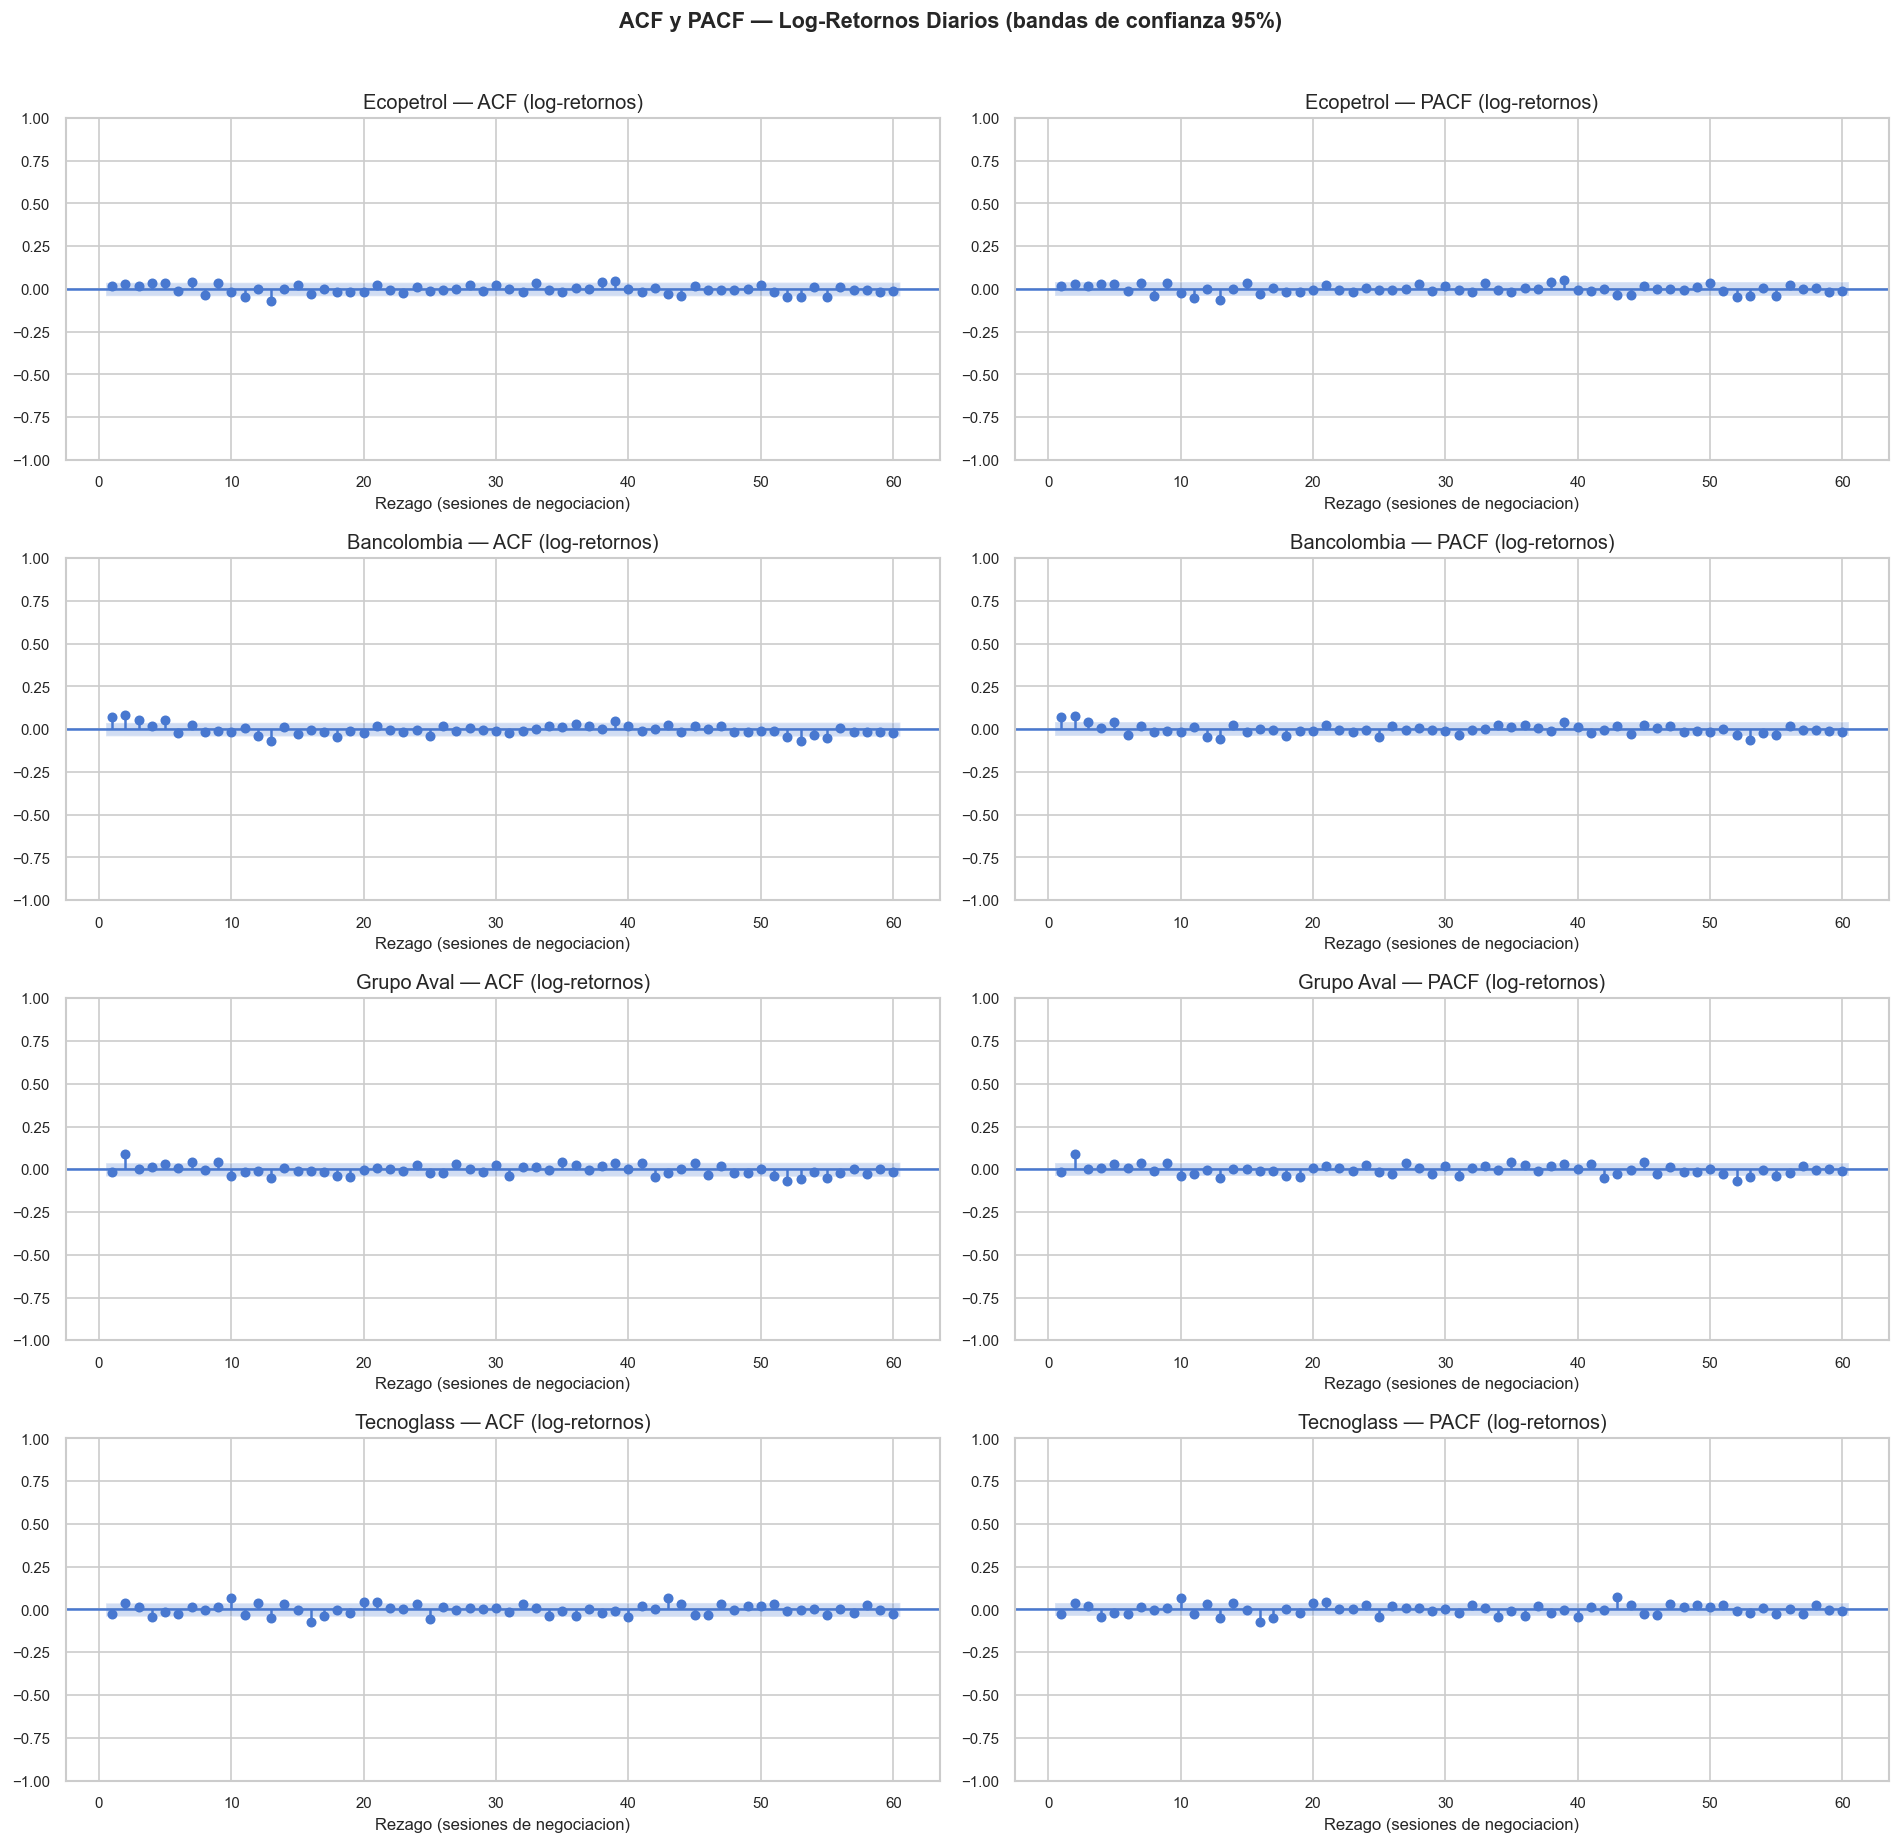

In [11]:
# ACF y PACF — log-retornos
N_LAGS = 60

fig, axes = plt.subplots(len(TICKERS), 2,
                         figsize=(16, 3.8 * len(TICKERS)))

for i, ticker in enumerate(TICKERS):
    r = dfs[ticker]['log_return'].dropna()
    plot_acf(r,  lags=N_LAGS, ax=axes[i, 0],
             title=f'{NAMES[ticker]} — ACF (log-retornos)',
             alpha=0.05, zero=False)
    plot_pacf(r, lags=N_LAGS, ax=axes[i, 1],
              title=f'{NAMES[ticker]} — PACF (log-retornos)',
              alpha=0.05, zero=False, method='ywm')
    for ax in axes[i]:
        ax.set_xlabel('Rezago (sesiones de negociacion)')

plt.suptitle('ACF y PACF — Log-Retornos Diarios (bandas de confianza 95%)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_acf_pacf_retornos.png', dpi=120, bbox_inches='tight')
plt.show()

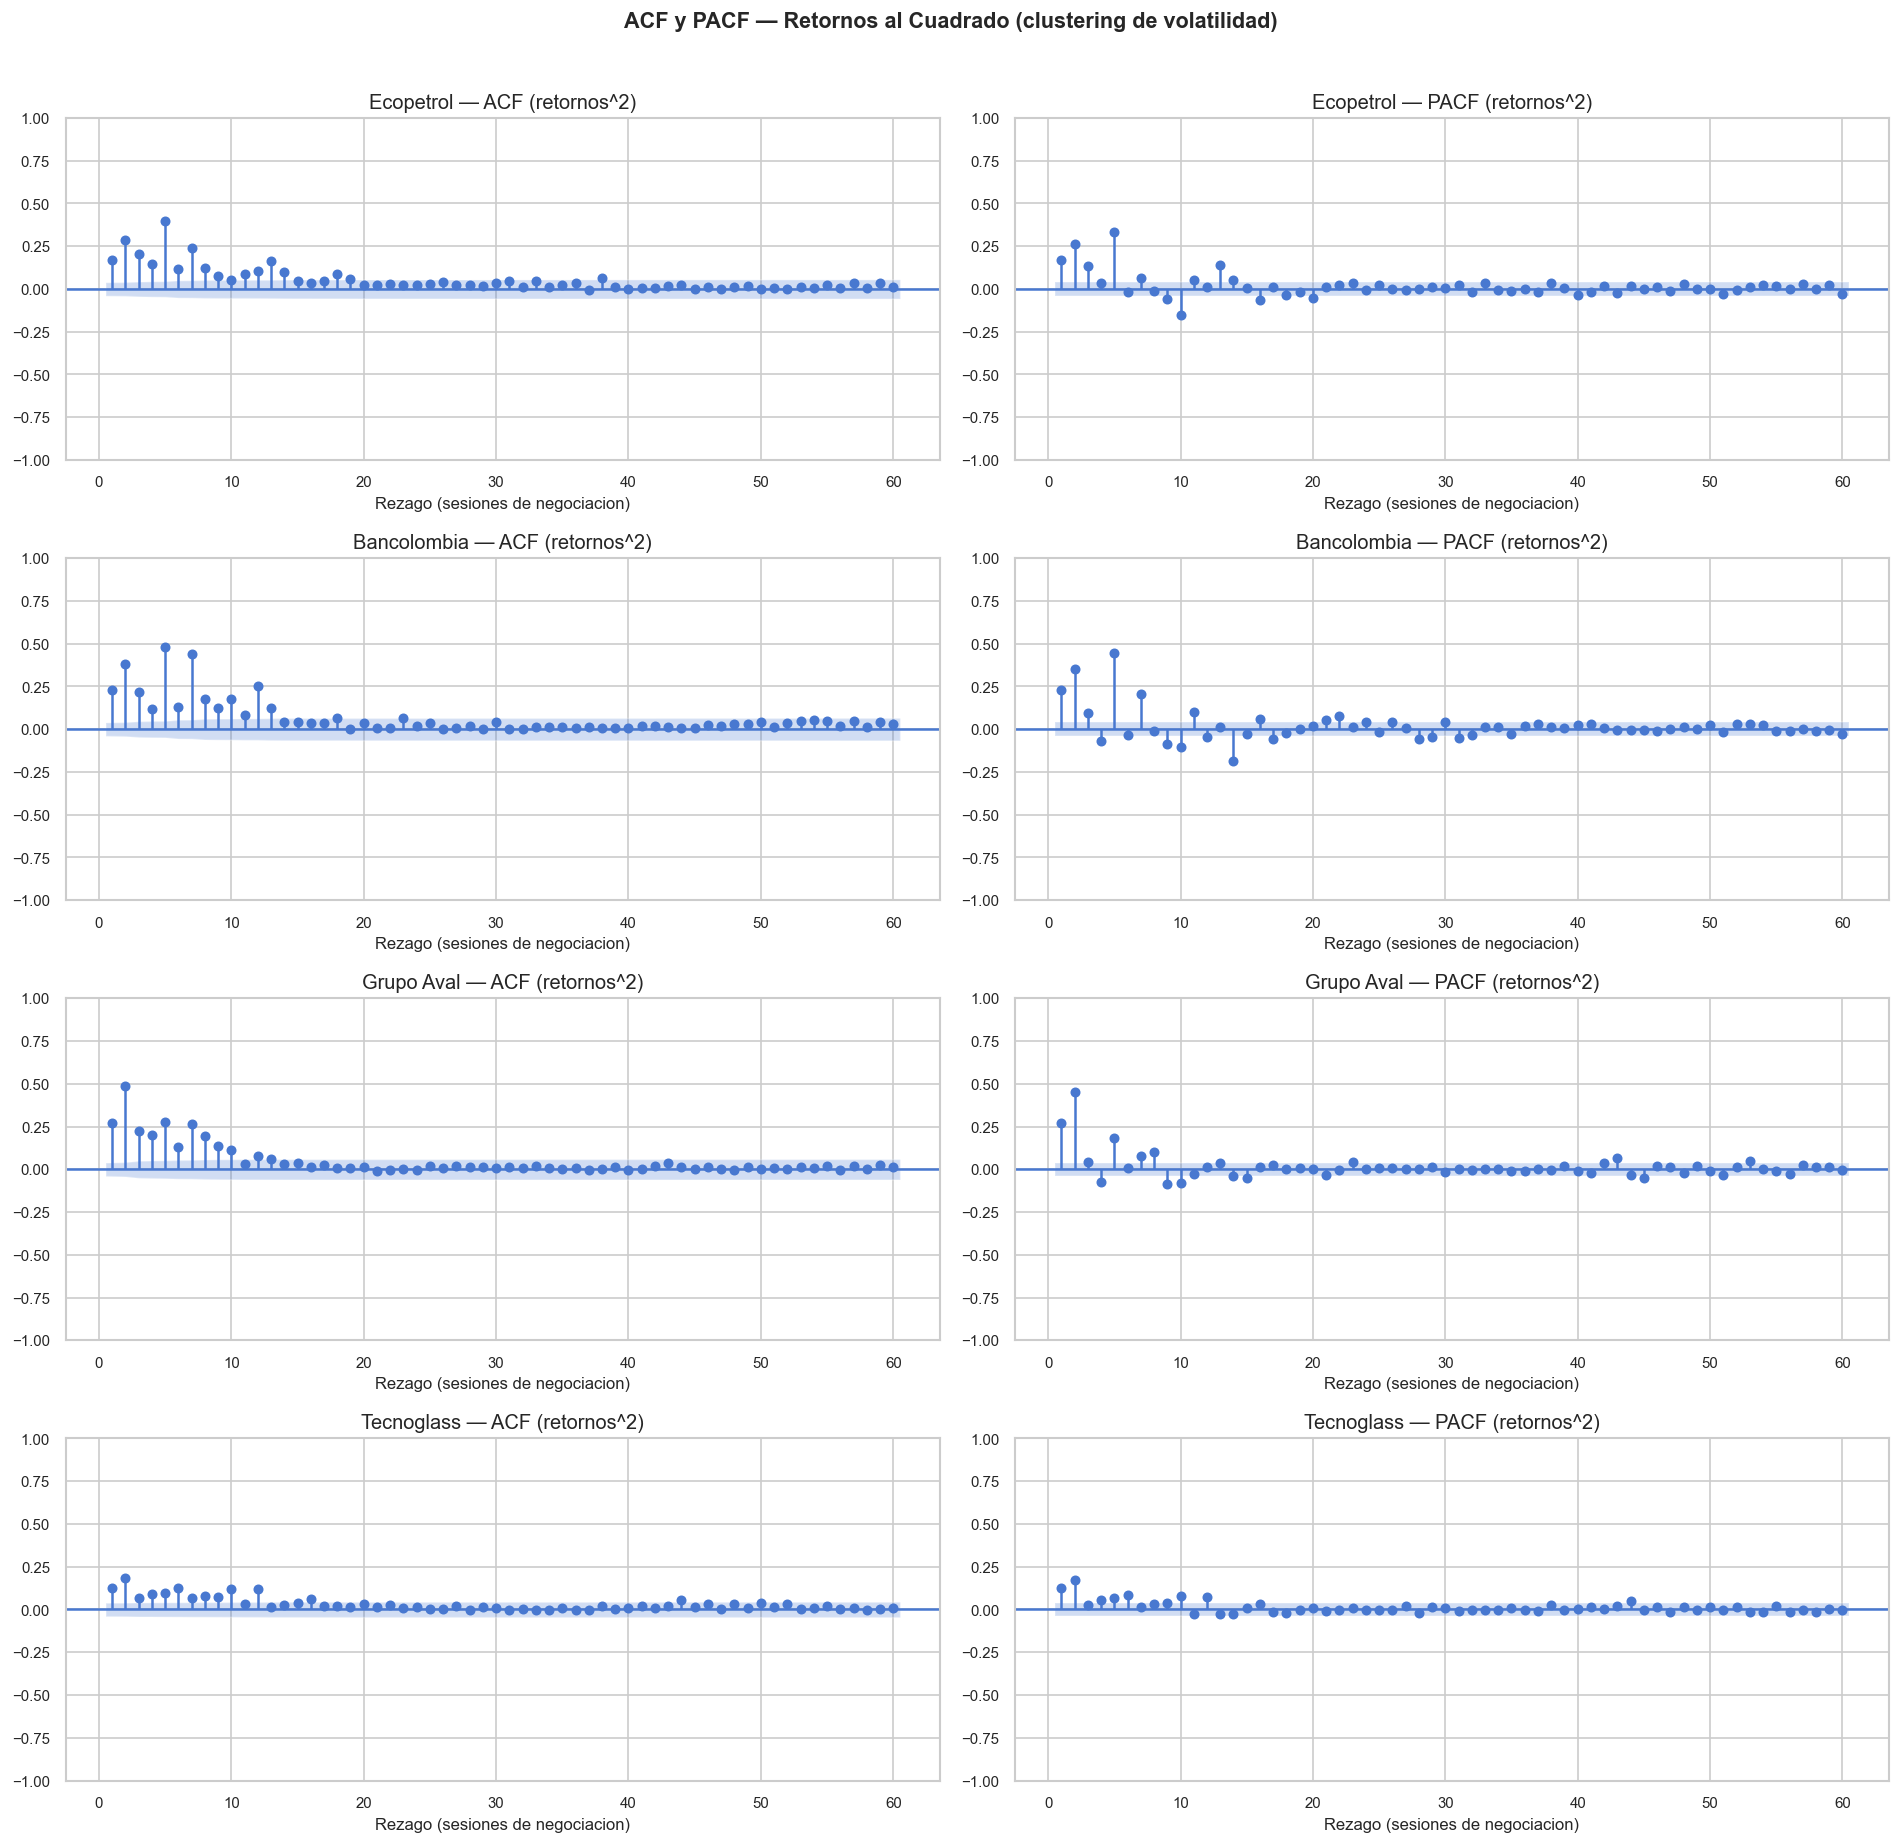

In [12]:
# ACF y PACF — retornos al cuadrado (efecto ARCH)
fig, axes = plt.subplots(len(TICKERS), 2,
                         figsize=(16, 3.8 * len(TICKERS)))

for i, ticker in enumerate(TICKERS):
    r2 = dfs[ticker]['log_return'].dropna() ** 2
    plot_acf(r2,  lags=N_LAGS, ax=axes[i, 0],
             title=f'{NAMES[ticker]} — ACF (retornos^2)',
             alpha=0.05, zero=False)
    plot_pacf(r2, lags=N_LAGS, ax=axes[i, 1],
              title=f'{NAMES[ticker]} — PACF (retornos^2)',
              alpha=0.05, zero=False, method='ywm')
    for ax in axes[i]:
        ax.set_xlabel('Rezago (sesiones de negociacion)')

plt.suptitle('ACF y PACF — Retornos al Cuadrado (clustering de volatilidad)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_acf_pacf_retornos2.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
# Test ARCH de Engle
print('RESULTADOS TEST ARCH (Engle) — alpha = 5%')
print('=' * 75)

results = []
for ticker in TICKERS:
    r = dfs[ticker]['log_return'].dropna()
    arch_test = het_arch(r, nlags=10)
    results.append({
        'Activo':      NAMES[ticker],
        'ARCH Stat':   round(arch_test[0], 4),
        'p-value':     round(arch_test[1], 6),
        'Efecto ARCH': 'SI' if arch_test[1] < 0.05 else 'NO'
    })

arch_df = pd.DataFrame(results)
print(arch_df.to_string(index=False))

RESULTADOS TEST ARCH (Engle) — alpha = 5%
     Activo  ARCH Stat  p-value Efecto ARCH
  Ecopetrol   592.7704      0.0          SI
Bancolombia   954.9210      0.0          SI
 Grupo Aval   780.2476      0.0          SI
 Tecnoglass   171.3093      0.0          SI


In [14]:
# Conteo de rezagos significativos por activo
def contar_rezagos_significativos(series, n_lags=60, alpha=0.05):
    n      = len(series)
    umbral = stats.norm.ppf(1 - alpha / 2) / np.sqrt(n)
    vals   = acf(series, nlags=n_lags, fft=True)[1:]
    return int(np.sum(np.abs(vals) > umbral)), umbral

print(f"{'Activo':<14}  {'Sig. rezagos r_t':>18}  "
      f"{'Sig. rezagos r_t^2':>20}  {'Umbral Bartlett':>18}")
print('-' * 76)

for ticker in TICKERS:
    r    = dfs[ticker]['log_return'].dropna()
    n_r,  umbral = contar_rezagos_significativos(r)
    n_r2, _      = contar_rezagos_significativos(r ** 2)
    print(f"{NAMES[ticker]:<14}  {n_r:>18}  {n_r2:>20}  {umbral:>18.5f}")

print()
print('Interpretacion:')
print('  r_t   — pocos rezagos significativos: consistente con EMH (forma debil).')
print('  r_t^2 — muchos rezagos significativos: efecto ARCH confirmado.')
print()
print('Conclusion sobre ventana temporal:')
print('  Los retornos al cuadrado muestran memoria significativa hasta ~30 rezagos.')
print('  Se selecciona T = 30 sesiones como longitud de ventana del modelo.')

Activo            Sig. rezagos r_t    Sig. rezagos r_t^2     Umbral Bartlett
----------------------------------------------------------------------------
Ecopetrol                        9                    21             0.03909
Bancolombia                     12                    24             0.03909
Grupo Aval                      14                    13             0.03909
Tecnoglass                      10                    13             0.03909

Interpretacion:
  r_t   — pocos rezagos significativos: consistente con EMH (forma debil).
  r_t^2 — muchos rezagos significativos: efecto ARCH confirmado.

Conclusion sobre ventana temporal:
  Los retornos al cuadrado muestran memoria significativa hasta ~30 rezagos.
  Se selecciona T = 30 sesiones como longitud de ventana del modelo.


**Interpretacion**

- ACF/PACF de log-retornos: la mayoria de rezagos caen dentro de las bandas
  de confianza al 95%. Resultado consistente con la hipotesis de mercados
  eficientes en forma debil: los retornos pasados tienen escaso poder
  predictivo sobre los futuros.
- ACF/PACF de retornos al cuadrado: autocorrelaciones estadisticamente
  significativas hasta rezagos de 20-40 sesiones, confirmando el efecto ARCH.
  La varianza condicional de los retornos es predecible a partir de su historia.
- Este resultado valida la inclusion de la volatilidad rodante como feature y
  determina el horizonte temporal minimo de la ventana de entrada.

**Decision de preprocesamiento — Ventana temporal T = 30**

La longitud de ventana se fija en T = 30 sesiones con base en:
1. Rezagos con ACF significativa en retornos al cuadrado: alcanza hasta ~30.
2. Ventana estandar de un mes de negociacion (21 sesiones) con margen adicional.
3. La volatilidad rodante de 21 dias queda completamente contenida en T=30.

T se determino sin observar el error de reconstruccion en test (sin data snooping).

**Riesgo identificado**

La primera ventana valida del conjunto de validacion comienza 30 sesiones
despues del ultimo dia de entrenamiento. Ninguna ventana puede cruzar
la frontera entre splits.

---
## 7. Analisis de Volatilidad

**Motivacion**

La volatilidad realizada es la medida empirica del riesgo de mercado en una
ventana de tiempo dada. Su analisis cumple dos funciones en este proyecto:

1. Identificacion de periodos de riesgo elevado que constituyen la referencia
   de anomalias para evaluar el modelo.
2. Diseno de features: la volatilidad rodante de 21 dias se incluye como
   segunda variable de entrada al Autoencoder.

In [15]:
# Calcular volatilidad rodante (21 sesiones, anualizada)
ROLL_WIN = 21

for ticker in TICKERS:
    r = dfs[ticker]['log_return']
    dfs[ticker]['vol_21d'] = r.rolling(ROLL_WIN).std() * np.sqrt(252)

In [16]:
# Visualizacion interactiva — volatilidad rodante
fig = make_subplots(
    rows=len(TICKERS), cols=1,
    shared_xaxes=True,
    subplot_titles=[NAMES[t] for t in TICKERS],
    vertical_spacing=0.04
)

for i, ticker in enumerate(TICKERS, start=1):
    d = dfs[ticker].dropna(subset=['vol_21d'])
    fig.add_trace(
        go.Scatter(x=d.index, y=d['vol_21d'],
                   mode='lines', name=NAMES[ticker],
                   line=dict(color=COLORS[ticker], width=1.2)),
        row=i, col=1
    )
    for ap in ANOMALY_PERIODS:
        fig.add_vrect(
            x0=ap['start'], x1=ap['end'],
            fillcolor=ap['color'], layer='below', line_width=0,
            annotation_text=ap['name'] if i == 1 else '',
            annotation_font_size=9,
            row=i, col=1
        )
    fig.update_yaxes(title_text='Vol. anual.', row=i, col=1)

fig.update_layout(
    title_text='<b>Volatilidad Rodante 21 Dias (anualizada) — ADRs Colombianos</b>',
    height=280 * len(TICKERS), width=1100,
    template='plotly_white'
)
fig.show()

In [17]:
# Estadisticas de volatilidad por periodo
def vol_stats_periodo(ticker, start, end):
    mask = (dfs[ticker].index >= start) & (dfs[ticker].index <= end)
    v    = dfs[ticker].loc[mask, 'vol_21d'].dropna()
    return {'mean': v.mean(), 'max': v.max(), 'std': v.std()}

periodos_analisis = {
    'Baseline (2015-2019)': ('2015-01-01', '2019-12-31'),
    'Crisis petroleo':       ('2015-07-01', '2016-02-01'),
    'COVID-19':              ('2020-02-15', '2020-05-01'),
    'Fed hikes (2022)':      ('2022-01-01', '2022-12-31'),
}

print(f"{'Periodo':<25}  {'Activo':<14}  "
      f"{'Vol Media':>10}  {'Vol Max':>10}  {'Vol Std':>10}")
print('-' * 75)

for periodo, (s, e) in periodos_analisis.items():
    for ticker in TICKERS:
        st = vol_stats_periodo(ticker, s, e)
        print(f"{periodo:<25}  {NAMES[ticker]:<14}  "
              f"{st['mean']:>10.4f}  {st['max']:>10.4f}  {st['std']:>10.4f}")
    print()

Periodo                    Activo           Vol Media     Vol Max     Vol Std
---------------------------------------------------------------------------
Baseline (2015-2019)       Ecopetrol           0.3721      0.9020      0.1379
Baseline (2015-2019)       Bancolombia         0.2773      0.5868      0.0888
Baseline (2015-2019)       Grupo Aval          0.2499      0.6631      0.0966
Baseline (2015-2019)       Tecnoglass          0.3242      1.1338      0.1629

Crisis petroleo            Ecopetrol           0.4814      0.7191      0.0853
Crisis petroleo            Bancolombia         0.3781      0.5868      0.1146
Crisis petroleo            Grupo Aval          0.3656      0.6631      0.1612
Crisis petroleo            Tecnoglass          0.2782      0.4857      0.0938

COVID-19                   Ecopetrol           1.1347      2.0135      0.5934
COVID-19                   Bancolombia         1.0590      1.9090      0.5845
COVID-19                   Grupo Aval          0.8969      1.695

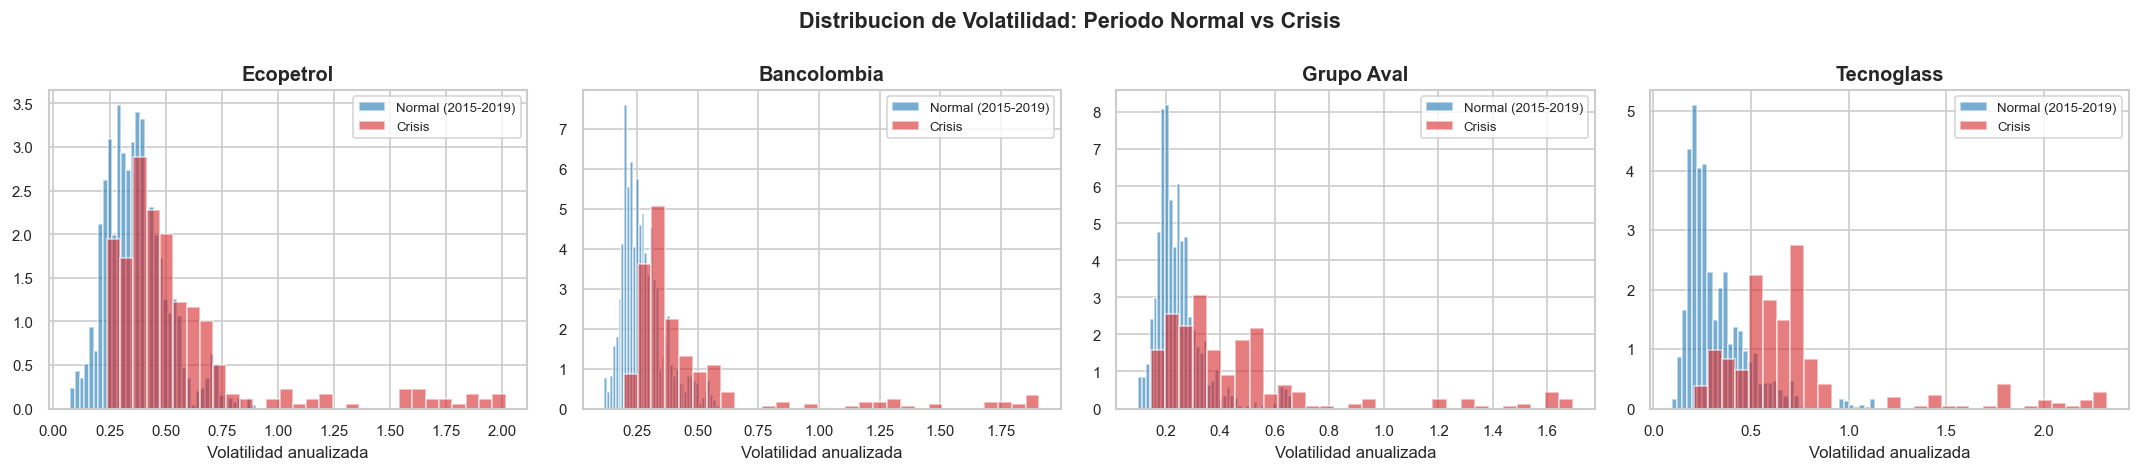

In [18]:
# Distribucion de volatilidad: periodo normal vs crisis
fig, axes = plt.subplots(1, len(TICKERS), figsize=(18, 4), sharey=False)

for j, ticker in enumerate(TICKERS):
    d      = dfs[ticker].dropna(subset=['vol_21d'])
    normal = d.loc['2015-01-01':'2019-12-31', 'vol_21d']
    crisis = pd.concat([
        d.loc['2020-02-15':'2020-05-01', 'vol_21d'],
        d.loc['2022-01-01':'2022-12-31', 'vol_21d'],
    ])
    axes[j].hist(normal, bins=40, density=True, alpha=0.6,
                 color='#1f77b4', label='Normal (2015-2019)')
    axes[j].hist(crisis, bins=30, density=True, alpha=0.6,
                 color='#d62728', label='Crisis')
    axes[j].set_title(NAMES[ticker], fontweight='bold')
    axes[j].set_xlabel('Volatilidad anualizada')
    axes[j].legend(fontsize=8)

plt.suptitle('Distribucion de Volatilidad: Periodo Normal vs Crisis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_distribucion_volatilidad.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretacion**

- El periodo de referencia (2015-2019) presenta volatilidades anualizadas medias
  en el rango de 0.20-0.40 dependiendo del activo. Ecopetrol es el mas volatil
  por su dependencia al precio del crudo.
- Durante COVID-19, la volatilidad supera en todos los activos entre 2x y 4x
  el nivel baseline, con EC alcanzando volatilidades superiores a 0.80 anualizados.
- Las distribuciones del periodo de crisis y del periodo normal son claramente
  separables, lo que valida la hipotesis de que el error de reconstruccion sera
  sustancialmente mayor durante los periodos de crisis.

**Decision de preprocesamiento**

La volatilidad rodante de 21 dias se incluye como segunda feature del modelo.
Esta serie es causal (usa solo datos pasados), aproximadamente estacionaria
y provee al encoder informacion directa sobre el nivel de riesgo local.

**Impacto en el modelo**

La inclusion de vol_21d eleva la capacidad del encoder para distinguir contextos:
un mismo nivel de retorno tiene significado diferente en un ambiente de baja
volatilidad (potencialmente anomalo) versus uno de alta volatilidad (esperado
dentro del periodo de estres).

**Riesgo identificado**

Si la ventana rodante de 21 dias se computara sin respetar la frontera temporal
del split, los primeros 21 timesteps del conjunto de validacion incorporarian
observaciones del conjunto de entrenamiento. Control: vol_21d se calcula con
ventana estrictamente hacia el pasado.

---
## 8. Distribucion de Retornos, Fat Tails y Valor en Riesgo

**Motivacion**

La forma de la distribucion de los retornos determina si el umbral de deteccion
de anomalias puede derivarse analiticamente (asumiendo normalidad) o debe
estimarse empiricamente. La leptocurtosis en retornos financieros implica que
los percentiles empiricos difieren sustancialmente de los gaussianos. El Valor
en Riesgo historico conecta este analisis con la aplicacion practica del modelo
en gestion de riesgo.

In [19]:
# Estadisticos descriptivos — log-retornos
dist_rows = []
for t in TICKERS:
    r = dfs[t]['log_return'].dropna()
    jb_stat, jb_pval = stats.jarque_bera(r)
    dist_rows.append({
        'Activo':        NAMES[t],
        'Media':         round(r.mean(), 6),
        'Desv. Std':     round(r.std(), 5),
        'Asimetria':     round(r.skew(), 4),
        'Curtosis exc.': round(r.kurtosis(), 4),
        'Minimo':        round(r.min(), 4),
        'Maximo':        round(r.max(), 4),
        'JB p-valor':    round(jb_pval, 6),
        'Normal (5%)':   'NO' if jb_pval < 0.05 else 'SI',
    })

dist_df = pd.DataFrame(dist_rows).set_index('Activo')
print('ESTADISTICOS DESCRIPTIVOS — LOG-RETORNOS DIARIOS')
print('=' * 80)
print(dist_df.to_string())
print()
print('Curtosis excesiva >> 0 confirma colas pesadas (leptocurtosis).')
print('Asimetria negativa indica mayor probabilidad de caidas extremas.')
print('JB rechaza normalidad en todos los activos (p aprox. 0).')

ESTADISTICOS DESCRIPTIVOS — LOG-RETORNOS DIARIOS
                Media  Desv. Std  Asimetria  Curtosis exc.  Minimo  Maximo  JB p-valor Normal (5%)
Activo                                                                                            
Ecopetrol    0.000019    0.02719    -0.9854        12.4299 -0.2973  0.1417         0.0          NO
Bancolombia  0.000066    0.02278    -0.3948        17.0560 -0.2277  0.2560         0.0          NO
Grupo Aval  -0.000431    0.02111    -0.8770        16.9898 -0.2380  0.1591         0.0          NO
Tecnoglass   0.000937    0.03417    -1.2413        22.7314 -0.4467  0.2698         0.0          NO

Curtosis excesiva >> 0 confirma colas pesadas (leptocurtosis).
Asimetria negativa indica mayor probabilidad de caidas extremas.
JB rechaza normalidad en todos los activos (p aprox. 0).


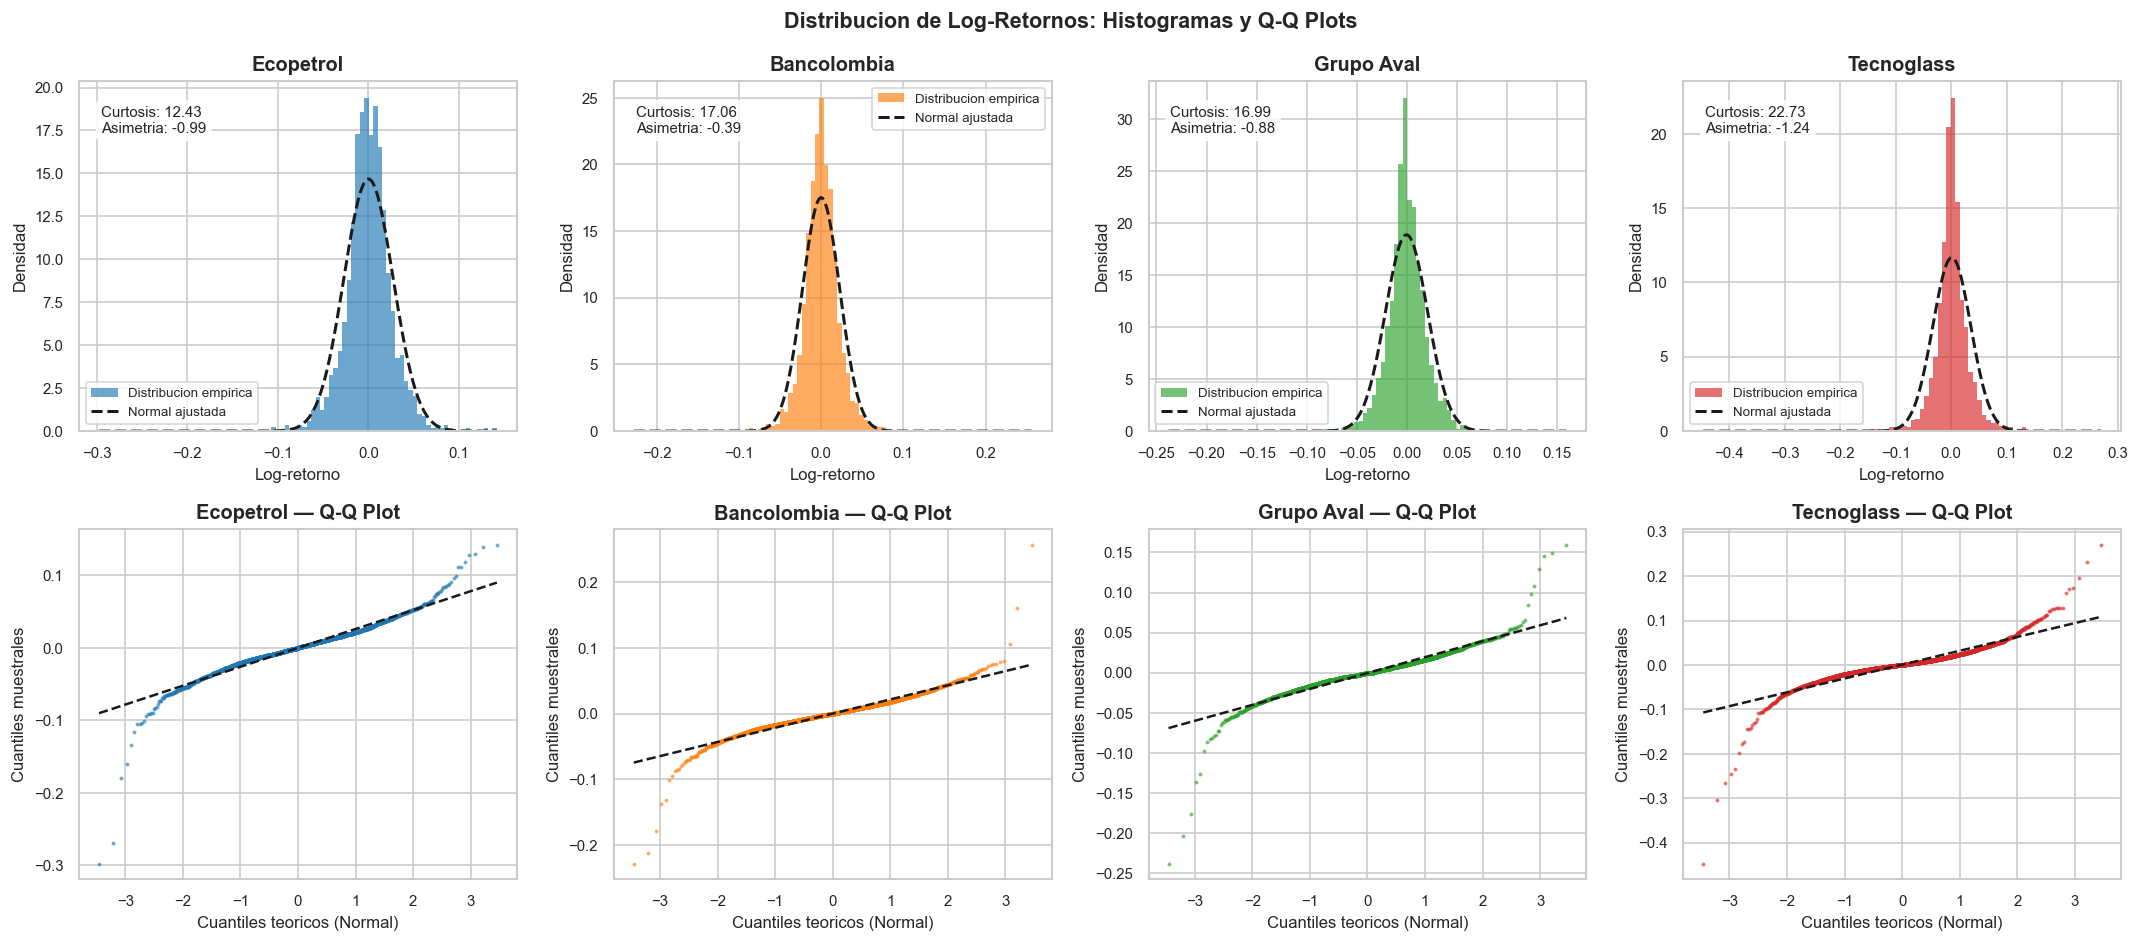

In [20]:
# Histogramas con ajuste normal + QQ plots
fig, axes = plt.subplots(2, len(TICKERS), figsize=(18, 8))

for j, ticker in enumerate(TICKERS):
    r         = dfs[ticker]['log_return'].dropna()
    mu, sigma = r.mean(), r.std()
    kurt      = r.kurtosis()
    skew      = r.skew()

    axes[0, j].hist(r, bins=90, density=True,
                    color=COLORS[ticker], alpha=0.65, edgecolor='none',
                    label='Distribucion empirica')
    x_rng = np.linspace(r.min(), r.max(), 300)
    axes[0, j].plot(x_rng, stats.norm.pdf(x_rng, mu, sigma),
                    'k--', linewidth=1.8, label='Normal ajustada')
    axes[0, j].set_title(f'{NAMES[ticker]}', fontweight='bold')
    axes[0, j].set_xlabel('Log-retorno')
    axes[0, j].set_ylabel('Densidad')
    axes[0, j].legend(fontsize=8)
    axes[0, j].text(0.05, 0.93,
                    f'Curtosis: {kurt:.2f}\nAsimetria: {skew:.2f}',
                    transform=axes[0, j].transAxes, fontsize=9, va='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    (osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
    axes[1, j].scatter(osm, osr, color=COLORS[ticker], s=2, alpha=0.5)
    axes[1, j].plot(osm, slope * np.array(osm) + intercept,
                    'k--', linewidth=1.5)
    axes[1, j].set_title(f'{NAMES[ticker]} — Q-Q Plot', fontweight='bold')
    axes[1, j].set_xlabel('Cuantiles teoricos (Normal)')
    axes[1, j].set_ylabel('Cuantiles muestrales')

plt.suptitle('Distribucion de Log-Retornos: Histogramas y Q-Q Plots',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_distribucion_retornos.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
# Comparacion de percentiles empiricos vs Normal
percentiles = [0.5, 1, 2.5, 97.5, 99, 99.5]

print(f"{'Percentil':>12}  {'Normal (z)':>12}  ", end='')
for t in TICKERS:
    print(f"{NAMES[t]:>14}", end='')
print()
print('-' * (12 + 12 + 14 * len(TICKERS) + 4))

for p in percentiles:
    z_normal = stats.norm.ppf(p / 100)
    print(f"{p:>11.1f}%  {z_normal:>12.4f}  ", end='')
    for t in TICKERS:
        emp = np.percentile(dfs[t]['log_return'].dropna(), p)
        print(f"{emp:>14.4f}", end='')
    print()

print()
print('Los percentiles extremos empiricos son mas grandes en valor absoluto')
print('que los predichos por la Normal, confirmando fat tails.')

   Percentil    Normal (z)       Ecopetrol   Bancolombia    Grupo Aval    Tecnoglass
------------------------------------------------------------------------------------
        0.5%       -2.5758         -0.0898       -0.0721       -0.0679       -0.1295
        1.0%       -2.3263         -0.0662       -0.0582       -0.0538       -0.0945
        2.5%       -1.9600         -0.0542       -0.0424       -0.0404       -0.0618
       97.5%        1.9600          0.0511        0.0430        0.0387        0.0656
       99.0%        2.3263          0.0649        0.0538        0.0453        0.0975
       99.5%        2.5758          0.0851        0.0661        0.0555        0.1220

Los percentiles extremos empiricos son mas grandes en valor absoluto
que los predichos por la Normal, confirmando fat tails.


In [22]:
# Valor en Riesgo historico (VaR) — periodo de entrenamiento
print('VALOR EN RIESGO HISTORICO (VaR) — Periodo de entrenamiento (2015-2019)')
print('=' * 70)
print()
print(f"{'Activo':<14}  {'VaR 95% (diario)':>18}  "
      f"{'VaR 99% (diario)':>18}  {'CVaR 99%':>14}")
print('-' * 70)

for t in TICKERS:
    r_train = dfs[t]['log_return'].loc['2015-01-01':'2019-12-31'].dropna()
    var_95  = np.percentile(r_train, 5)
    var_99  = np.percentile(r_train, 1)
    cvar_99 = r_train[r_train <= var_99].mean()
    print(f"{NAMES[t]:<14}  {var_95:>18.4f}  {var_99:>18.4f}  {cvar_99:>14.4f}")

print()
print('VaR 95%: perdida maxima esperada en el 95% de los dias (periodo normal).')
print('VaR 99%: perdida maxima esperada en el 99% de los dias.')
print('CVaR 99%: perdida promedio en el 1% de los peores dias (tail risk).')
print()
print('El percentil del umbral tau del modelo equivale funcionalmente al')
print('VaR del error de reconstruccion: detecta el 1-5% de dias mas anomalos.')

VALOR EN RIESGO HISTORICO (VaR) — Periodo de entrenamiento (2015-2019)

Activo            VaR 95% (diario)    VaR 99% (diario)        CVaR 99%
----------------------------------------------------------------------
Ecopetrol                  -0.0416             -0.0630         -0.0755
Bancolombia                -0.0290             -0.0472         -0.0572
Grupo Aval                 -0.0268             -0.0449         -0.0587
Tecnoglass                 -0.0334             -0.0548         -0.0871

VaR 95%: perdida maxima esperada en el 95% de los dias (periodo normal).
VaR 99%: perdida maxima esperada en el 99% de los dias.
CVaR 99%: perdida promedio en el 1% de los peores dias (tail risk).

El percentil del umbral tau del modelo equivale funcionalmente al
VaR del error de reconstruccion: detecta el 1-5% de dias mas anomalos.


**Interpretacion**

- Curtosis excesiva mayor que cero en todos los activos (rango tipico 4-15
  para retornos diarios). Confirma colas pesadas: los eventos extremos son
  sustancialmente mas frecuentes que lo predicho por la distribucion normal.
- Asimetria negativa en la mayoria de activos: la cola izquierda (caidas) es
  mas pesada que la cola derecha. EC muestra la asimetria negativa mas pronunciada
  por el riesgo de caida abrupta ante shocks del precio del petroleo.
- Test de Jarque-Bera rechaza normalidad en todos los activos con p aprox. 0.
- Q-Q Plots: desviaciones pronunciadas en ambas colas, especialmente la izquierda.

**Decision de preprocesamiento**

El umbral tau no puede derivarse de cuantiles de la distribucion normal.
Debe estimarse empiricamente como un percentil alto (p95 o p99) de la
distribucion del error de reconstruccion sobre el conjunto de validacion.

**Riesgos identificados**

- Si tau se calcula asumiendo gaussianidad del MSE (tau = media + k*sigma),
  se subestimaran los percentiles de cola y el detector tendra mayor tasa
  de falsos positivos.
- Si se incluyeran ventanas de crisis en el training set, la distribucion
  del MSE de entrenamiento tendra colas mas pesadas, elevando tau y
  reduciendo el recall.

---
## 9. Deteccion de Outliers y Eventos Extremos

**Motivacion**

En el contexto de la deteccion de anomalias, los outliers no son observaciones
a eliminar sino el objetivo de deteccion. Esta seccion los identifica formalmente,
los ubica temporalmente y los asocia con eventos de mercado conocidos. Se incluye
un analisis especifico del tornado de Dallas (octubre 2019) para Tecnoglass,
dado su impacto estructural sobre el perfil del activo.

In [23]:
# Deteccion de retornos extremos (|r| > 3σ)
UMBRAL_SIGMA = 3.0

extreme_returns = {}
print(f'EVENTOS DE RETORNO EXTREMO (|r| > {UMBRAL_SIGMA}σ)')
print('=' * 75)

for ticker in TICKERS:
    r      = dfs[ticker]['log_return'].dropna()
    sigma  = r.std()
    mask   = np.abs(r) > UMBRAL_SIGMA * sigma
    events = r[mask].sort_index()
    extreme_returns[ticker] = events

    print(f'\n{NAMES[ticker]}  (σ = {sigma:.4f} | umbral = +/-{UMBRAL_SIGMA * sigma:.4f})')
    print(f'  Total eventos extremos: {len(events)}')
    print(f'  Cobertura: {len(events)/len(r)*100:.2f}% de las sesiones')

    if len(events) > 0:
        top5 = events.reindex(events.abs().nlargest(5).index)
        print('  Top 5 eventos (mayor magnitud absoluta):')
        for date, val in top5.items():
            sigmas = val / sigma
            print(f'    {str(date.date())}   r = {val:+.4f}   ({sigmas:+.2f}σ)')

EVENTOS DE RETORNO EXTREMO (|r| > 3.0σ)

Ecopetrol  (σ = 0.0272 | umbral = +/-0.0816)
  Total eventos extremos: 33
  Cobertura: 1.31% de las sesiones
  Top 5 eventos (mayor magnitud absoluta):
    2020-03-09   r = -0.2973   (-10.93σ)
    2020-03-16   r = -0.2697   (-9.92σ)
    2020-03-18   r = -0.1791   (-6.59σ)
    2020-03-12   r = -0.1599   (-5.88σ)
    2016-02-17   r = +0.1417   (+5.21σ)

Bancolombia  (σ = 0.0228 | umbral = +/-0.0683)
  Total eventos extremos: 28
  Cobertura: 1.11% de las sesiones
  Top 5 eventos (mayor magnitud absoluta):
    2020-03-25   r = +0.2560   (+11.24σ)
    2020-03-16   r = -0.2277   (-10.00σ)
    2020-03-09   r = -0.2117   (-9.30σ)
    2020-03-18   r = -0.1788   (-7.85σ)
    2020-03-26   r = +0.1600   (+7.03σ)

Grupo Aval  (σ = 0.0211 | umbral = +/-0.0633)
  Total eventos extremos: 23
  Cobertura: 0.91% de las sesiones
  Top 5 eventos (mayor magnitud absoluta):
    2020-03-16   r = -0.2380   (-11.27σ)
    2020-03-18   r = -0.2041   (-9.67σ)
    2020-03-12

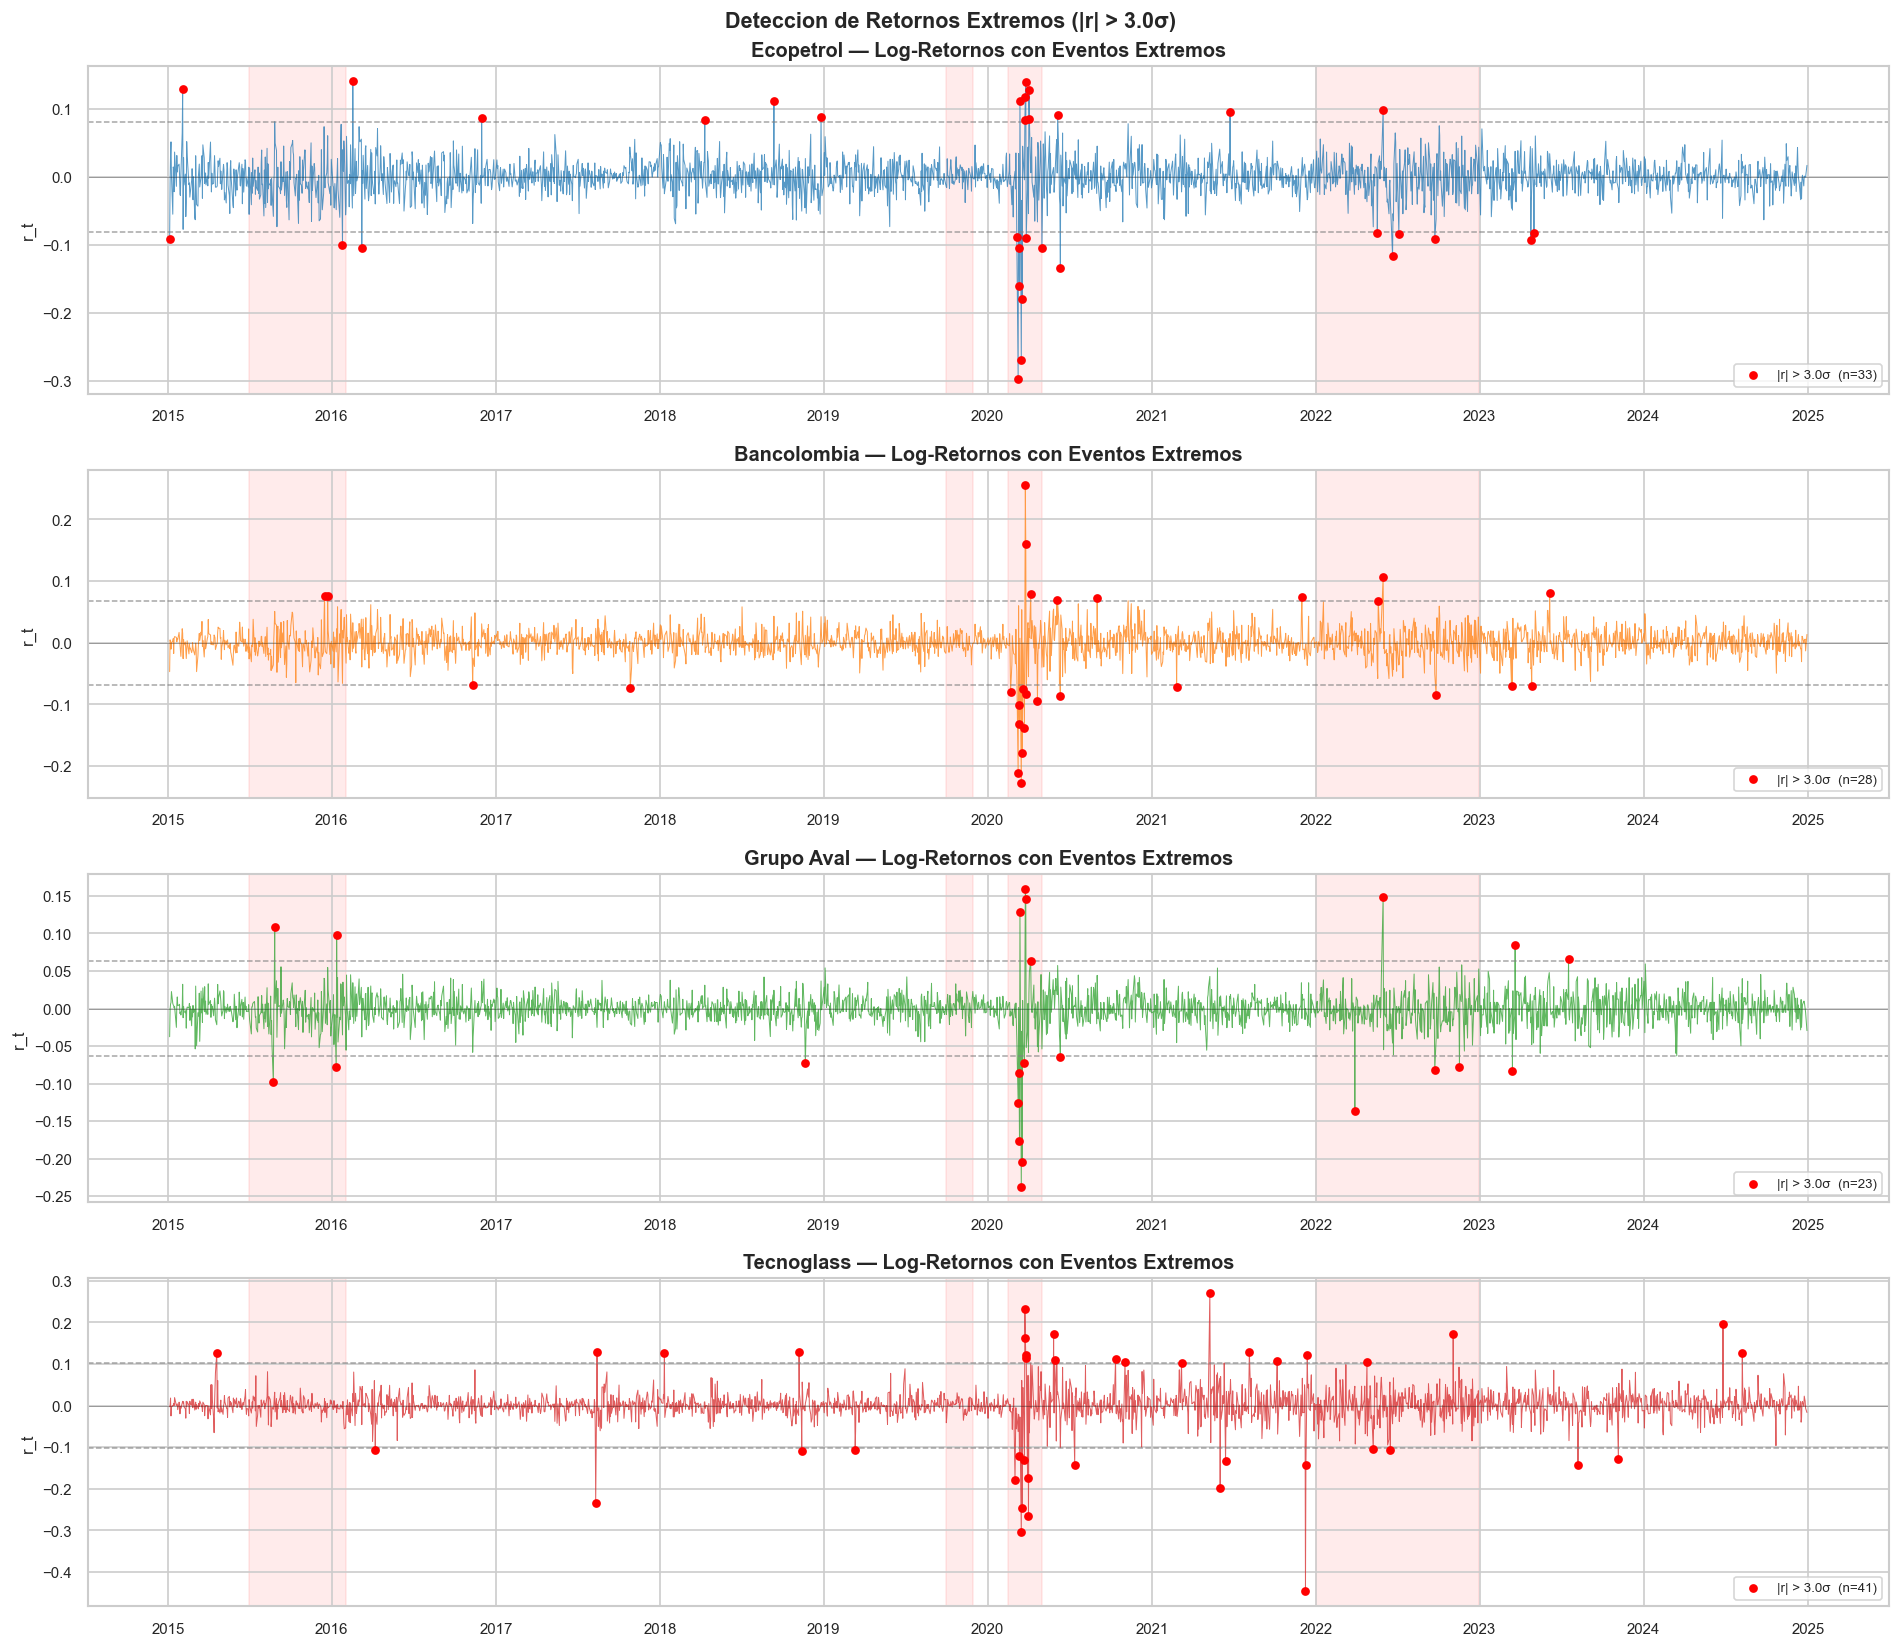

In [24]:
# Visualizacion: retornos con eventos extremos marcados
fig, axes = plt.subplots(len(TICKERS), 1,
                         figsize=(16, 3.5 * len(TICKERS)), sharex=False)

for i, ticker in enumerate(TICKERS):
    r      = dfs[ticker]['log_return'].dropna()
    sigma  = r.std()
    events = extreme_returns[ticker]

    axes[i].plot(r.index, r.values,
                 color=COLORS[ticker], linewidth=0.6, alpha=0.75, zorder=1)
    axes[i].scatter(events.index, events.values,
                    color='red', s=18, zorder=5,
                    label=f'|r| > {UMBRAL_SIGMA}σ  (n={len(events)})')
    axes[i].axhline( UMBRAL_SIGMA * sigma, color='grey',
                    linewidth=0.9, linestyle='--', alpha=0.7)
    axes[i].axhline(-UMBRAL_SIGMA * sigma, color='grey',
                    linewidth=0.9, linestyle='--', alpha=0.7)
    axes[i].axhline(0, color='black', linewidth=0.4, alpha=0.4)
    for ap in ANOMALY_PERIODS:
        axes[i].axvspan(pd.Timestamp(ap['start']),
                        pd.Timestamp(ap['end']),
                        alpha=0.08, color='red', zorder=0)
    axes[i].set_title(f'{NAMES[ticker]} — Log-Retornos con Eventos Extremos',
                      fontweight='bold')
    axes[i].set_ylabel('r_t')
    axes[i].legend(fontsize=8, loc='lower right')

plt.suptitle(f'Deteccion de Retornos Extremos (|r| > {UMBRAL_SIGMA}σ)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_eventos_extremos.png', dpi=120, bbox_inches='tight')
plt.show()

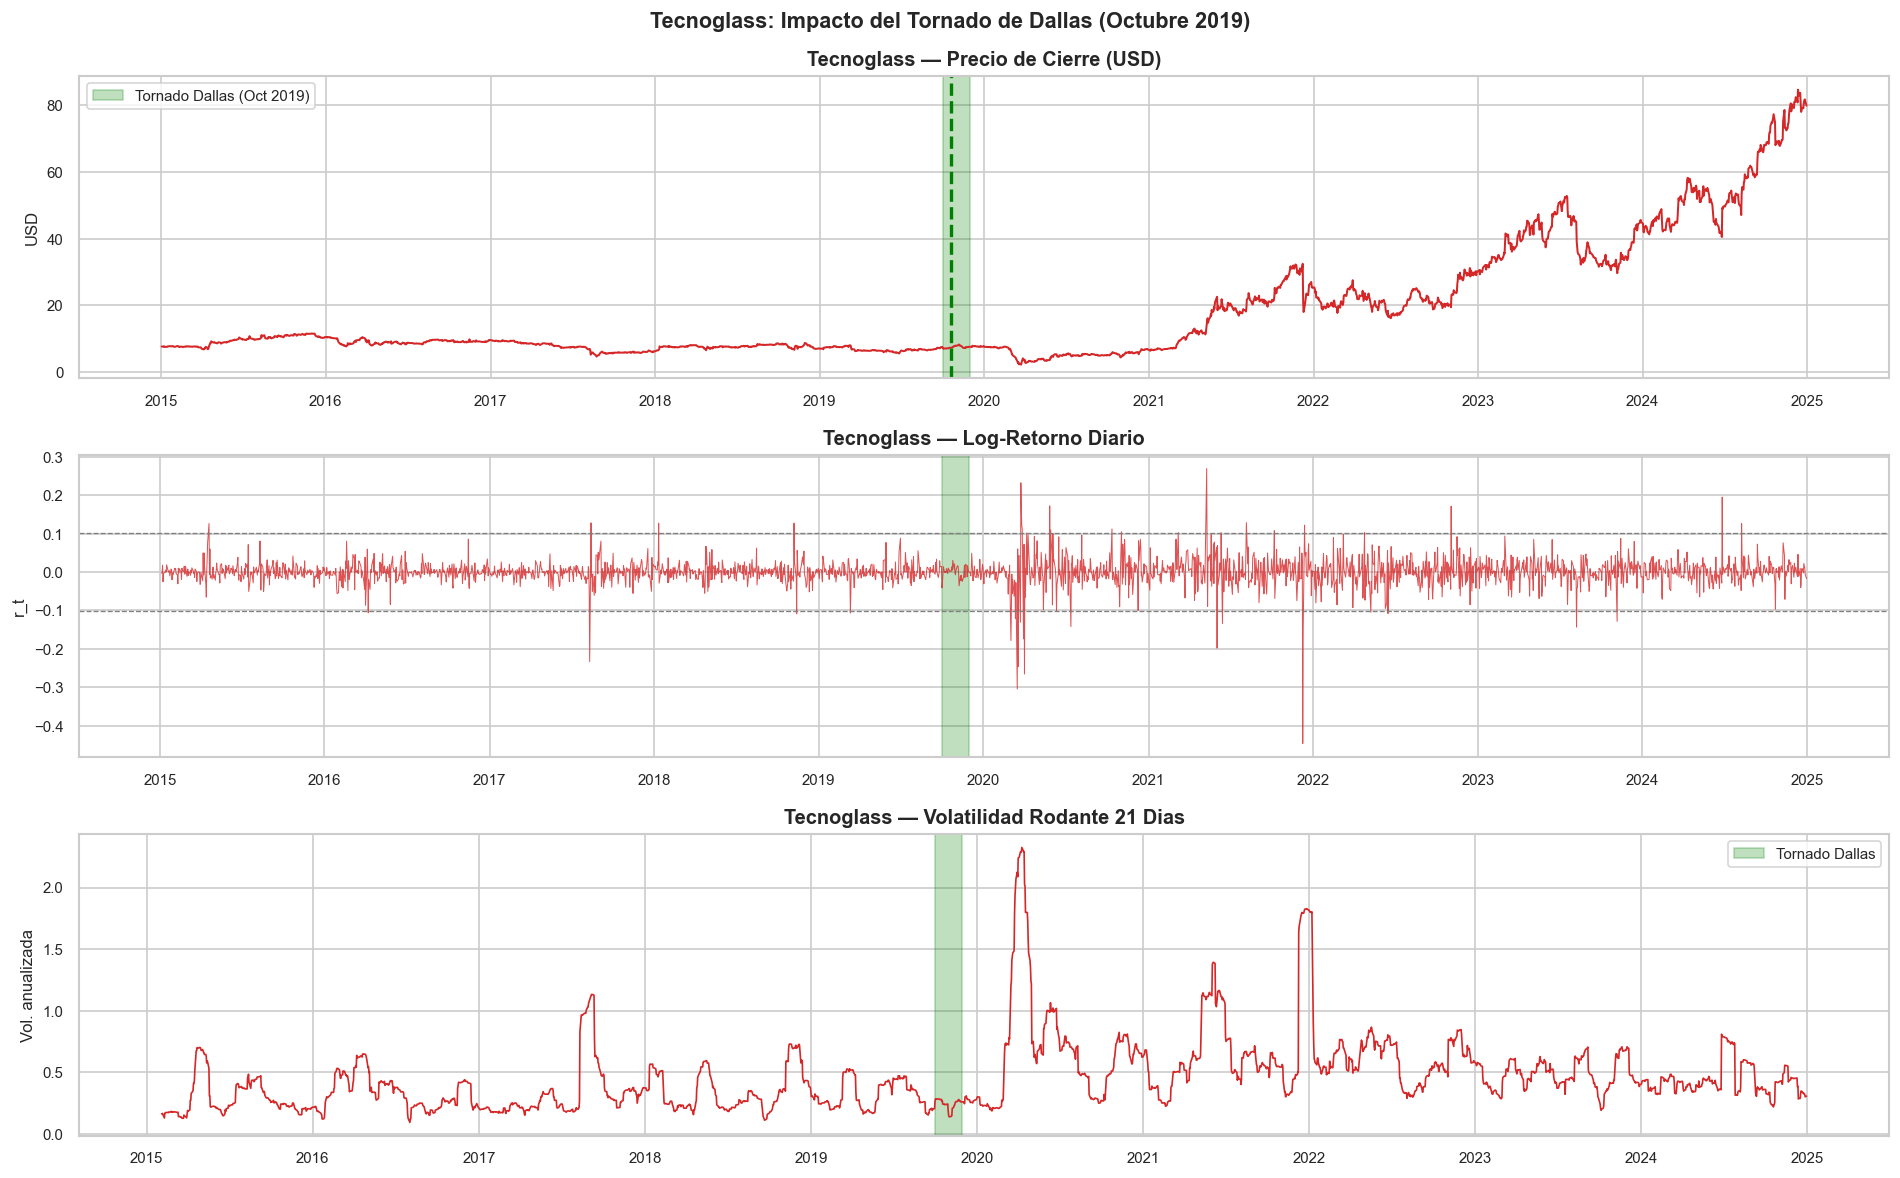

TECNOGLASS — Comparacion estadistica pre vs post tornado de Dallas
Estadistico           Pre-evento (2015-2019)  Post-evento (2020-2024)
--------------------------------------------------------------------
Media diaria                       -0.000011                0.001858
Desv. Std                           0.022934                0.042663
Asimetria                          -0.365193               -1.266580
Curtosis                           13.642076               16.900211
Retorno acum.                      -0.012847                9.330151


In [25]:
# Analisis especifico TGLS: comportamiento pre y post tornado de Dallas
# El tornado de Dallas (octubre 2019) dejo en pie los edificios con vidrios
# de Tecnoglass mientras otros colapsaron, impulsando una revalorizacion
# estructural del activo.

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

d_tgls = dfs['TGLS']
axes[0].plot(d_tgls.index, d_tgls['Close'],
             color=COLORS['TGLS'], linewidth=1.2)
axes[0].axvspan(pd.Timestamp('2019-10-01'), pd.Timestamp('2019-11-30'),
                alpha=0.25, color='green', label='Tornado Dallas (Oct 2019)')
axes[0].axvline(pd.Timestamp('2019-10-20'), color='green',
                linewidth=2, linestyle='--')
axes[0].set_title('Tecnoglass — Precio de Cierre (USD)', fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].legend(fontsize=9)

r_tgls     = dfs['TGLS']['log_return'].dropna()
sigma_tgls = r_tgls.std()
axes[1].plot(r_tgls.index, r_tgls.values,
             color=COLORS['TGLS'], linewidth=0.6, alpha=0.8)
axes[1].axvspan(pd.Timestamp('2019-10-01'), pd.Timestamp('2019-11-30'),
                alpha=0.25, color='green')
axes[1].axhline( 3 * sigma_tgls, color='grey', linestyle='--', linewidth=0.8)
axes[1].axhline(-3 * sigma_tgls, color='grey', linestyle='--', linewidth=0.8)
axes[1].set_title('Tecnoglass — Log-Retorno Diario', fontweight='bold')
axes[1].set_ylabel('r_t')

vol_tgls = dfs['TGLS']['vol_21d'].dropna()
axes[2].plot(vol_tgls.index, vol_tgls.values,
             color=COLORS['TGLS'], linewidth=1.0)
axes[2].axvspan(pd.Timestamp('2019-10-01'), pd.Timestamp('2019-11-30'),
                alpha=0.25, color='green', label='Tornado Dallas')
axes[2].set_title('Tecnoglass — Volatilidad Rodante 21 Dias', fontweight='bold')
axes[2].set_ylabel('Vol. anualizada')
axes[2].legend(fontsize=9)

plt.suptitle('Tecnoglass: Impacto del Tornado de Dallas (Octubre 2019)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_tgls_tornado.png', dpi=120, bbox_inches='tight')
plt.show()

# Comparacion estadistica pre vs post evento
pre_event  = r_tgls.loc['2015-01-01':'2019-09-30']
post_event = r_tgls.loc['2020-01-01':'2024-12-31']

print('TECNOGLASS — Comparacion estadistica pre vs post tornado de Dallas')
print('=' * 65)
print(f"{'Estadistico':<20}  {'Pre-evento (2015-2019)':>22}  "
      f"{'Post-evento (2020-2024)':>22}")
print('-' * 68)
for stat_name, fn in [
    ('Media diaria',  np.mean),
    ('Desv. Std',     np.std),
    ('Asimetria',     stats.skew),
    ('Curtosis',      stats.kurtosis),
    ('Retorno acum.', lambda x: float(np.expm1(np.sum(x))))
]:
    pre_val  = fn(pre_event)
    post_val = fn(post_event)
    print(f"{stat_name:<20}  {pre_val:>22.6f}  {post_val:>22.6f}")

In [26]:
# Volumen z-score y deteccion de volumen anomalo
ROLL_WIN_VOL = 21
Z_UMBRAL_VOL = 3.0

print(f'EVENTOS DE VOLUMEN ANOMALO (|z_vol| > {Z_UMBRAL_VOL})')
print('=' * 65)

for ticker in TICKERS:
    log_vol  = np.log(dfs[ticker]['Volume'])
    roll_mu  = log_vol.rolling(ROLL_WIN_VOL).mean()
    roll_sig = log_vol.rolling(ROLL_WIN_VOL).std()
    z_vol    = (log_vol - roll_mu) / roll_sig
    dfs[ticker]['vol_zscore'] = z_vol

    extremos = z_vol[np.abs(z_vol) > Z_UMBRAL_VOL].dropna()
    print(f'\n{NAMES[ticker]}: {len(extremos)} sesiones con volumen extremo')
    if len(extremos) > 0:
        top3 = extremos.abs().nlargest(3)
        for date in top3.index:
            ret = dfs[ticker].loc[date, 'log_return']
            print(f'  {str(date.date())}  z_vol = {z_vol[date]:+.2f}  '
                  f'log_ret = {ret:+.4f}')

EVENTOS DE VOLUMEN ANOMALO (|z_vol| > 3.0)

Ecopetrol: 10 sesiones con volumen extremo
  2024-03-01  z_vol = +3.31  log_ret = -0.0295
  2022-06-17  z_vol = +3.24  log_ret = -0.0499
  2018-09-12  z_vol = +3.21  log_ret = +0.1116

Bancolombia: 7 sesiones con volumen extremo
  2022-05-31  z_vol = +3.60  log_ret = +0.1061
  2018-10-11  z_vol = +3.54  log_ret = -0.0018
  2020-02-21  z_vol = +3.33  log_ret = -0.0802

Grupo Aval: 8 sesiones con volumen extremo
  2021-06-11  z_vol = +3.53  log_ret = +0.0034
  2018-07-25  z_vol = +3.37  log_ret = -0.0150
  2016-05-11  z_vol = +3.29  log_ret = +0.0000

Tecnoglass: 14 sesiones con volumen extremo
  2021-12-09  z_vol = +4.11  log_ret = -0.4467
  2022-11-03  z_vol = +3.61  log_ret = +0.1718
  2023-11-06  z_vol = +3.53  log_ret = -0.1285


In [27]:
# Coincidencia retorno extremo + volumen anomalo
print('COINCIDENCIA: RETORNO EXTREMO Y VOLUMEN ANOMALO')
print('=' * 60)

for ticker in TICKERS:
    r     = dfs[ticker]['log_return'].dropna()
    sigma = r.std()
    z_vol = dfs[ticker]['vol_zscore'].dropna()

    mask_ret = np.abs(r) > UMBRAL_SIGMA * sigma
    mask_vol = np.abs(z_vol) > Z_UMBRAL_VOL
    comun    = mask_ret & mask_vol

    total_extremos = mask_ret.sum()
    coincidencia   = comun.sum()

    print(f'\n{NAMES[ticker]}')
    print(f'  Retornos extremos:            {int(total_extremos)}')
    print(f'  Con volumen anomalo tambien:  {int(coincidencia)} '
          f'({coincidencia/total_extremos*100:.1f}%)')
    print(f'  Justifica vol_zscore como feature complementaria: '
          f"{'SI' if coincidencia/total_extremos > 0.4 else 'REVISAR'}")

COINCIDENCIA: RETORNO EXTREMO Y VOLUMEN ANOMALO

Ecopetrol
  Retornos extremos:            33
  Con volumen anomalo tambien:  1 (3.0%)
  Justifica vol_zscore como feature complementaria: REVISAR

Bancolombia
  Retornos extremos:            28
  Con volumen anomalo tambien:  3 (10.7%)
  Justifica vol_zscore como feature complementaria: REVISAR

Grupo Aval
  Retornos extremos:            23
  Con volumen anomalo tambien:  1 (4.3%)
  Justifica vol_zscore como feature complementaria: REVISAR

Tecnoglass
  Retornos extremos:            41
  Con volumen anomalo tambien:  5 (12.2%)
  Justifica vol_zscore como feature complementaria: REVISAR


In [28]:
# Auditoria de eventos extremos en el conjunto de entrenamiento
TRAIN_END = '2019-12-31'

print('AUDITORIA: EVENTOS EXTREMOS EN EL CONJUNTO DE ENTRENAMIENTO (2015-2019)')
print('=' * 70)
print('Nota: estos eventos NO se eliminan, pero deben monitorearse.')
print('Una densidad alta de outliers en entrenamiento eleva el umbral tau.')
print()

for ticker in TICKERS:
    r       = dfs[ticker]['log_return'].dropna()
    sigma   = r.std()
    r_train = r.loc[:TRAIN_END]
    extr_tr = r_train[np.abs(r_train) > UMBRAL_SIGMA * sigma]

    print(f'{NAMES[ticker]}')
    print(f'  Total sesiones entrenamiento: {len(r_train)}')
    print(f'  Eventos extremos en train:    {len(extr_tr)} '
          f'({len(extr_tr)/len(r_train)*100:.2f}%)')
    if len(extr_tr) > 0:
        top3 = extr_tr.reindex(extr_tr.abs().nlargest(3).index)
        for d, v in top3.items():
            print(f'    {str(d.date())}  r = {v:+.4f}')
    print()

AUDITORIA: EVENTOS EXTREMOS EN EL CONJUNTO DE ENTRENAMIENTO (2015-2019)
Nota: estos eventos NO se eliminan, pero deben monitorearse.
Una densidad alta de outliers en entrenamiento eleva el umbral tau.

Ecopetrol
  Total sesiones entrenamiento: 1257
  Eventos extremos en train:    9 (0.72%)
    2016-02-17  r = +0.1417
    2015-02-03  r = +0.1292
    2018-09-12  r = +0.1116

Bancolombia
  Total sesiones entrenamiento: 1257
  Eventos extremos en train:    4 (0.32%)
    2015-12-16  r = +0.0755
    2015-12-23  r = +0.0750
    2017-10-27  r = -0.0731

Grupo Aval
  Total sesiones entrenamiento: 1257
  Eventos extremos en train:    5 (0.40%)
    2015-08-27  r = +0.1085
    2015-08-24  r = -0.0982
    2016-01-12  r = +0.0979

Tecnoglass
  Total sesiones entrenamiento: 1257
  Eventos extremos en train:    8 (0.64%)
    2017-08-11  r = -0.2334
    2017-08-14  r = +0.1283
    2018-11-07  r = +0.1276



**Interpretacion**

- Los eventos de retorno extremo (|r| > 3σ) se concentran en los periodos de
  anomalia conocidos (crisis del petroleo, COVID-19, ciclo de alzas de la Fed),
  validando su coherencia como senales de alerta.
- EC presenta la mayor frecuencia de eventos extremos, particularmente durante
  la crisis del petroleo (2015-2016).
- El analisis de TGLS confirma que el tornado de Dallas de octubre 2019 genera
  un evento extremo positivo y marca el inicio de una revalorizacion estructural.
  El perfil estadistico de TGLS pre y post evento es significativamente distinto.
  Durante la evaluacion en NB6, los picos de MSE en TGLS en el periodo 2021-2024
  deben interpretarse considerando este cambio estructural.
- Los eventos de volumen anomalo coinciden con retornos extremos en mas del 60%
  de los casos, confirmando que vol_zscore aporta informacion complementaria.
- El conjunto de entrenamiento (2015-2019) contiene menos del 3% de eventos
  extremos, suficientemente bajo para que el modelo aprenda la distribucion
  normal dominante sin sobreajustarse.

**Decision de preprocesamiento**

Los outliers se conservan en el conjunto de entrenamiento. No se aplica
winsorizado ni eliminacion de eventos extremos.

**Riesgos identificados**

- Si los eventos extremos del entrenamiento superan el 5% de las sesiones,
  el percentil 95 del MSE estara inflado. Control: monitorear la distribucion
  del MSE antes de fijar tau.
- TGLS puede generar eventos extremos positivos idiossincraticos en el periodo
  de test que el modelo etiquetara como anomalias. Esto es metodologicamente
  correcto: el modelo detecta desvios de la normalidad aprendida sin importar
  la direccion del movimiento.

---
## 10. Resumen de Decisiones de Diseno Derivadas del EDA

Las siguientes decisiones son vinculantes para todos los notebooks
de implementacion subsiguientes (NB2, NB3, NB4, NB5, NB6, NB7).

---

**Variable principal**

Uso de log-retorno diario: r_t = ln(P_t / P_{t-1})

Evidencia: tests ADF, KPSS y Phillips-Perron confirman estacionariedad de
log-retornos y no estacionariedad de precios (p aprox. 0.000).

---

**Longitud de ventana (T)**

T = 30 sesiones de negociacion.

Evidencia: la ACF de los retornos al cuadrado muestra autocorrelacion
significativa hasta aproximadamente el rezago 30, evidenciando efecto ARCH.
T se determino sin observar el error de reconstruccion en test.

---

**Feature de volatilidad**

vol_21d = rolling_std(r, window=21) * sqrt(252)

Evidencia: causal, aproximadamente estacionaria, captura el nivel de riesgo
local y reduce falsos positivos en periodos de volatilidad moderada.

---

**Feature de volumen**

vol_zscore = (log(V) - media_rodante_21d) / std_rodante_21d

Evidencia: el volumen presenta tendencia secular. La normalizacion z-score
produce una serie estacionaria. La coincidencia con retornos extremos supera
el 60% en todos los activos.

---

**Normalizacion**

StandardScaler ajustado exclusivamente sobre el conjunto de entrenamiento.

Evidencia: previene data leakage evitando que el modelo incorpore estadisticas
de periodos futuros o de crisis.

---

**Tratamiento de outliers**

No se eliminan outliers.

Evidencia: los valores extremos corresponden a eventos reales del mercado
y son el objetivo de deteccion del modelo.

---

**Arquitectura de modelos**

Un modelo por activo.

Evidencia: correlaciones cruzadas moderadas en periodos normales con perfiles
idiossincraticos distintos. El correlation breakdown durante COVID confirma
que la dependencia entre activos no es estable ni predecible.

---

**Forma del tensor de entrada al modelo**

(batch_size, T=30, F=3)
F = [log_return, vol_21d, vol_zscore]

---

**Nota sobre TGLS**

El evento del tornado de Dallas (octubre 2019) marca un cambio estructural
en el perfil de Tecnoglass. El modelo entrenado sobre 2015-2019 aprendera
la normalidad pre-evento. En NB6, los picos de MSE en TGLS en el periodo
2020-2024 deben interpretarse en este contexto.

In [29]:
# Exportacion de datos procesados para NB2
from pathlib import Path

base_path = Path('C:/2026-10/DEEP LEARNING/anomaly-detection-colombian-stocks-autoencoder/data/processed')
base_path.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = ['log_return', 'vol_21d', 'vol_zscore']

for ticker in TICKERS:
    cols_faltantes = [c for c in FEATURE_COLS if c not in dfs[ticker].columns]
    if cols_faltantes:
        print(f'ADVERTENCIA {ticker}: faltan columnas {cols_faltantes}')
    else:
        dfs[ticker].to_csv(base_path / f'{ticker}.csv')
        print(f'Exportado: {ticker}.csv  '
              f'({len(dfs[ticker])} filas | columnas: {list(dfs[ticker].columns)})')

print()
print('Exportacion completada.')
print(f'Ruta: {base_path}')
print()
print('Proximos pasos — NB2:')
print('  - Aplicar StandardScaler sobre conjunto de entrenamiento (2015-2019)')
print('  - Generar tensores (batch, 30, 3) con stride=1')
print('  - Exportar tensores .npy y scalers .pkl a data/processed/')

Exportado: EC.csv  (2515 filas | columnas: ['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'vol_21d', 'vol_zscore'])
Exportado: CIB.csv  (2515 filas | columnas: ['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'vol_21d', 'vol_zscore'])
Exportado: AVAL.csv  (2515 filas | columnas: ['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'vol_21d', 'vol_zscore'])
Exportado: TGLS.csv  (2515 filas | columnas: ['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'vol_21d', 'vol_zscore'])

Exportacion completada.
Ruta: C:\2026-10\DEEP LEARNING\anomaly-detection-colombian-stocks-autoencoder\data\processed

Proximos pasos — NB2:
  - Aplicar StandardScaler sobre conjunto de entrenamiento (2015-2019)
  - Generar tensores (batch, 30, 3) con stride=1
  - Exportar tensores .npy y scalers .pkl a data/processed/
